<h3 style='color:darkred'>Comparative Analysis of Machine Learning and Deep Learning Models for Short-Term Indian Stock Market Prediction Using Technical Indicators</h3>

1. Data Collection
2. Data Loading
3. Data Understanding
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Target Variable Creation
7. Data Preprocessing
8. Feature Selection
9. Train-Test Split
10. Random Forest Model
11. Random Forest Hyperparameter Tuning
12. XGBoost Model
13. XGBoost Hyperparameter Tuning
14. LSTM Model
15. Model Performance Comparison
16. Future Stock Movement Prediction
17. Conclusion

## 1. Import common Libraries


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection
Historical stock market data was collected from Yahoo Finance using the yfinance Python library. Five representative companies were selected from different sectors of the Indian stock market to enable a comparative analysis across industries.

Selected Companies:
- Infosys – Information Technology (IT)
- HDFC Bank – Banking
- Reliance Industries – Energy
- Maruti Suzuki – Automobile
- Sun Pharmaceutical – Healthcare

The daily historical stock prices were downloaded for the period from 1 January 2020 to 1 January 2025.

In [2]:
# # ==========================================================
# # 1. DATA COLLECTION
# # ==========================================================

# import yfinance as yf
# import os

# # Create folder to store downloaded datasets
# os.makedirs("Datasets", exist_ok=True)

# # Selected companies
# stocks = {
#     "Infosys": "INFY.NS",
#     "HDFC_Bank": "HDFCBANK.NS",
#     "Sun_Pharma": "SUNPHARMA.NS",
#     "Reliance": "RELIANCE.NS",
#     "Maruti": "MARUTI.NS"
# }

# # Download historical stock data
# for name, symbol in stocks.items():

#     df = yf.download(
#         symbol,
#         start="2020-01-01",
#         end="2025-01-01",
#         progress=False
#     )

#     df.to_csv(f"Datasets/{name}.csv")

#     print(f"{name} dataset downloaded successfully.")

## 3. Data Loading
This section loads the downloaded stock dataset into a pandas DataFrame. Since the data downloaded from Yahoo Finance contains additional header rows, the dataset is cleaned before further analysis.

In [3]:
# ==========================================================
# 3. DATA LOADING
# ==========================================================

company = "Reliance"

df = pd.read_csv(f"Datasets/{company}.csv")

print("Dataset Loaded Successfully")
print(f"Company : {company}")
print(f"Shape   : {df.shape}")
print(f"First Five rows : {df.head()}")

Dataset Loaded Successfully
Company : Reliance
Shape   : (1240, 6)
First Five rows :         Price              Close               High                Low  \
0      Ticker        RELIANCE.NS        RELIANCE.NS        RELIANCE.NS   
1        Date                NaN                NaN                NaN   
2  2020-01-01  672.2161865234375  680.0088516309808  670.3905321258029   
3  2020-01-02  683.6602783203125  686.1762083080744  673.2849207275859   
4  2020-01-03  684.4840698242188  686.4878962665452  678.1831277621862   

                Open       Volume  
0        RELIANCE.NS  RELIANCE.NS  
1                NaN          NaN  
2  675.9566705310696     14004468  
3  673.2849207275859     17710316  
4  682.6360622006584     20984698  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1240 non-null   object
 1   Close   1239 non-null   object
 2   High    1239 non-null   object
 3   Low     1239 non-null   object
 4   Open    1239 non-null   object
 5   Volume  1239 non-null   object
dtypes: object(6)
memory usage: 58.3+ KB


## 4. Data Cleaning

In [5]:
# ==========================================================
# 4. DATA CLEANING
# ==========================================================

# Remove unnecessary header rows
df = df.iloc[2:].reset_index(drop=True)

# Rename columns
df.columns = [
    "date",
    "close",
    "high",
    "low",
    "open",
    "volume"
]

# Convert data types
df["date"] = pd.to_datetime(df["date"])

numeric_columns = [
    "close",
    "high",
    "low",
    "open",
    "volume"
]

df[numeric_columns] = df[numeric_columns].astype(float)

# Sort by date
df = df.sort_values("date").reset_index(drop=True)

print("Dataset cleaned successfully.")

Dataset cleaned successfully.


In [6]:
df.head(5)

,date,close,high,low,open,volume
0,2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468.0
1,2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316.0
2,2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698.0
3,2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177.0
4,2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622.0


## 5. Data Understanding

In [7]:
# ==========================================================
# 5. DATA UNDERSTANDING
# ==========================================================

print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)
print(df.columns.tolist())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

print("\n")

print("="*60)
print("First Five Rows")
print("="*60)

df.head()

Dataset Shape
(1238, 6)


Column Names
['date', 'close', 'high', 'low', 'open', 'volume']


Missing Values
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


Data Types
date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume           float64
dtype: object


First Five Rows


,date,close,high,low,open,volume
0,2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468.0
1,2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316.0
2,2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698.0
3,2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177.0
4,2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1238 non-null   datetime64[ns]
 1   close   1238 non-null   float64       
 2   high    1238 non-null   float64       
 3   low     1238 non-null   float64       
 4   open    1238 non-null   float64       
 5   volume  1238 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 58.2 KB


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the historical stock market data before feature engineering and model development. This step helps identify trends, distributions, relationships among variables, and potential anomalies in the dataset.

### 6.1 Dataset Statistics

This section provides an overview of the dataset, including its dimensions, missing values, data types, and descriptive statistics.

In [9]:
# ==========================================================
# 6.1 DATASET STATISTICS
# ==========================================================

print("="*70)
print("DATASET SHAPE")
print("="*70)
print(df.shape)

print("\n")

print("="*70)
print("COLUMN NAMES")
print("="*70)
print(df.columns.tolist())

print("\n")

print("="*70)
print("DATA TYPES")
print("="*70)
print(df.dtypes)

print("\n")

print("="*70)
print("MISSING VALUES")
print("="*70)
print(df.isnull().sum())

print("\n")

print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
display(df.describe())

DATASET SHAPE
(1238, 6)


COLUMN NAMES
['date', 'close', 'high', 'low', 'open', 'volume']


DATA TYPES
date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume           float64
dtype: object


MISSING VALUES
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


SUMMARY STATISTICS


,date,close,high,low,open,volume
count,1238,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,2022-06-28 20:01:33.053311744,1095.098187,1107.006455,1084.237081,1095.962057,1.951391e+07
min,2020-01-01 00:00:00,393.662384,423.029534,389.921900,407.978572,1.705656e+06
25%,2021-03-27 00:00:00,951.000824,962.121236,942.435859,951.571360,1.009199e+07
50%,2022-06-27 12:00:00,1115.586853,1127.810136,1106.010392,1116.995422,1.425293e+07
75%,2023-09-25 18:00:00,1219.325256,1232.958550,1207.933317,1219.190640,2.203644e+07
max,2024-12-31 00:00:00,1581.824463,1589.630354,1566.607850,1585.332001,1.426834e+08
std,NaN,230.477780,230.698652,230.092007,230.365314,1.612248e+07


### 6.2 Daily Closing Price Trend

This visualization shows how the daily closing price changed over the selected study period (2020–2025). It helps identify long-term trends, periods of high volatility, and major price movements.

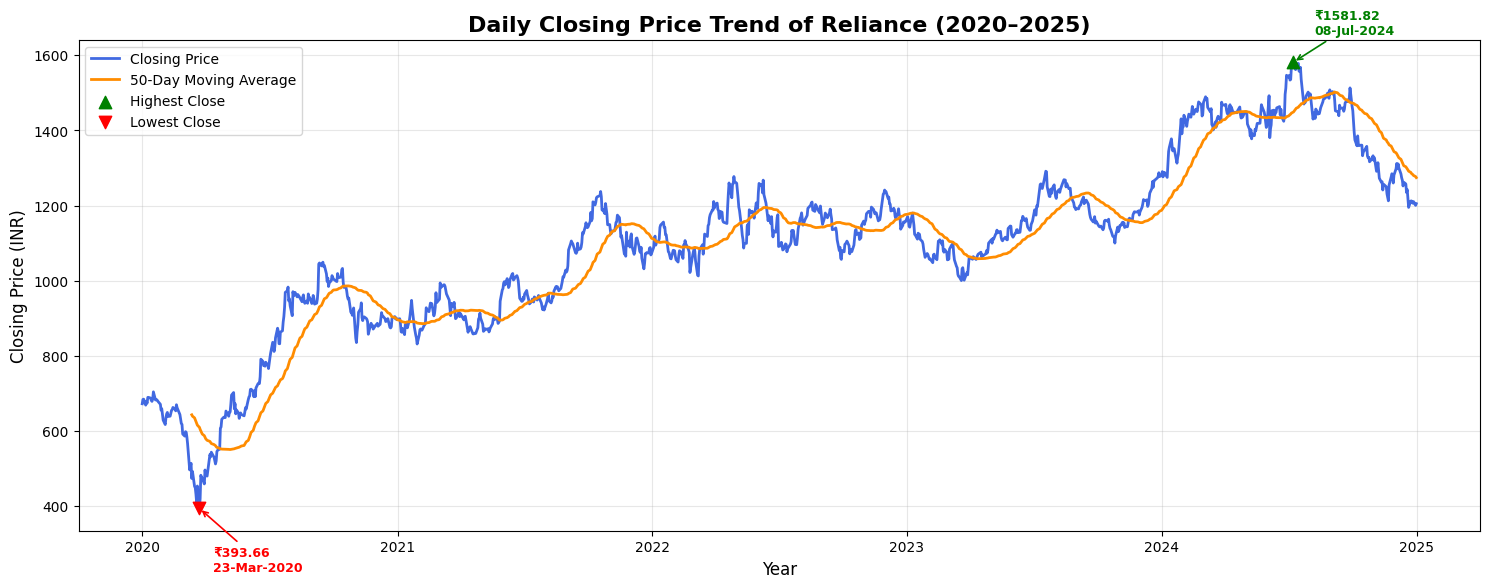

In [10]:
# ==========================================================
# 6.2 DAILY CLOSING PRICE TREND
# ==========================================================

import os
import matplotlib.dates as mdates

# Create Results folder
os.makedirs(f"Results/{company}", exist_ok=True)

# Calculate 50-Day Moving Average
df["ma50"] = df["close"].rolling(window=50).mean()

# Highest and Lowest Closing Price
max_idx = df["close"].idxmax()
min_idx = df["close"].idxmin()

# Create Figure
plt.figure(figsize=(15, 6))

# Closing Price
plt.plot(
    df["date"],
    df["close"],
    color="royalblue",
    linewidth=2,
    label="Closing Price"
)

# 50-Day Moving Average
plt.plot(
    df["date"],
    df["ma50"],
    color="darkorange",
    linewidth=2,
    label="50-Day Moving Average"
)


# Highest Closing Price
plt.scatter(
    df.loc[max_idx, "date"],
    df.loc[max_idx, "close"],
    color="green",
    marker="^",
    s=80,
    zorder=5,
    label="Highest Close"
)

plt.annotate(
    f'₹{df.loc[max_idx,"close"]:.2f}\n{df.loc[max_idx,"date"].strftime("%d-%b-%Y")}',
    xy=(df.loc[max_idx,"date"], df.loc[max_idx,"close"]),
    xytext=(15,20),
    textcoords="offset points",
    fontsize=9,
    color="green",
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="green",
        lw=1.2
    )
)

# Lowest Closing Price
plt.scatter(
    df.loc[min_idx, "date"],
    df.loc[min_idx, "close"],
    color="red",
    marker="v",
    s=80,
    zorder=5,
    label="Lowest Close"
)

plt.annotate(
    f'₹{df.loc[min_idx,"close"]:.2f}\n{df.loc[min_idx,"date"].strftime("%d-%b-%Y")}',
    xy=(df.loc[min_idx,"date"], df.loc[min_idx,"close"]),
    xytext=(10,-45),
    textcoords="offset points",
    fontsize=9,
    color="red",
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)

# X-axis Formatting (Years Only)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Labels & Title
plt.title(
    f"Daily Closing Price Trend of {company} (2020–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Closing Price (INR)", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(loc="upper left")

plt.tight_layout()

plt.show()

#### Observation

The daily closing price trend shows that the stock experienced both upward and downward movements during the study period, reflecting different market conditions. The highest and lowest closing prices highlight periods of significant market activity, while the 50-day moving average smooths short-term fluctuations and clearly illustrates the overall long-term trend. Overall, the stock demonstrated an increasing trend with intermittent periods of volatility.

### 6.3 Weekday Market Behaviour

This section analyses how the stock behaves on different trading days of the week. The average closing price and average daily return are calculated for each weekday to identify any consistent market patterns. This analysis provides insight into whether certain weekdays exhibit stronger or weaker market performance.

#### 6.3.1 Average Closing Price by Weekday

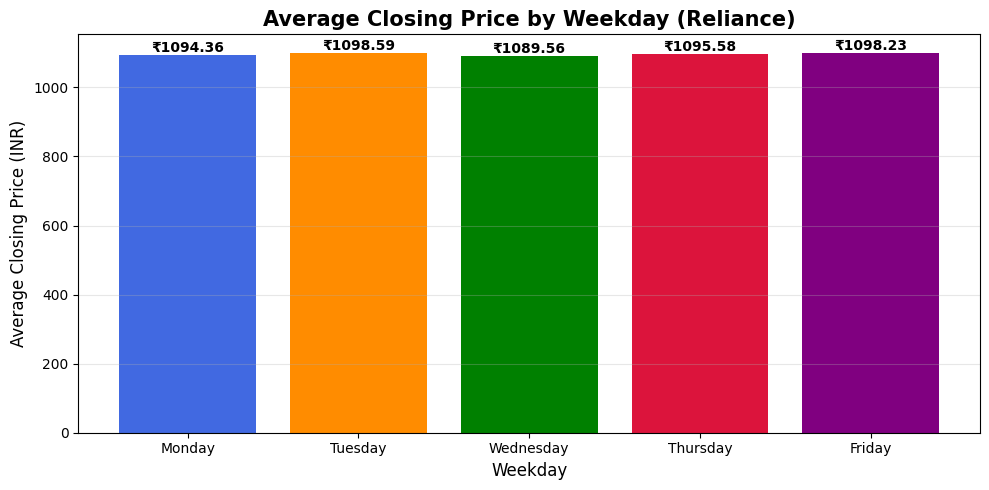

In [11]:
# ==========================================================
# 6.3.1 AVERAGE CLOSING PRICE BY WEEKDAY
# ==========================================================

# Weekday Name
df["weekday"] = df["date"].dt.day_name()

# Maintain Weekday Order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

# Average Closing Price
weekday_close = (
    df.groupby("weekday")["close"]
      .mean()
      .reindex(weekday_order)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    weekday_close.index,
    weekday_close.values,
    color=["royalblue","darkorange","green","crimson","purple"]
)

# Value Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    f"Average Closing Price by Weekday ({company})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weekday", fontsize=12)

plt.ylabel("Average Closing Price (INR)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

##### Observation

The bar chart compares the average closing price across the five trading days. Small differences indicate relatively stable pricing throughout the week, whereas larger differences may suggest recurring weekday-specific market behaviour.

#### 6.3.2 Average Daily Return by Weekday

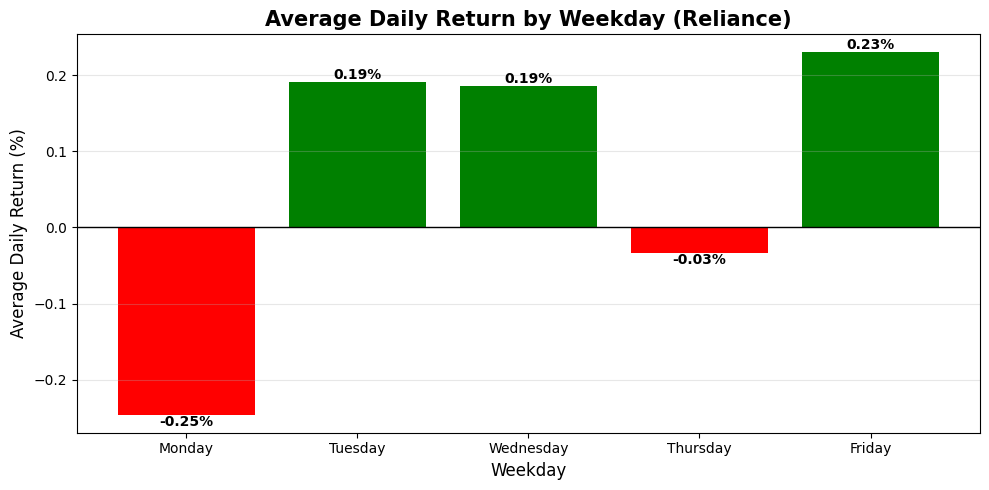

In [12]:
# ==========================================================
# 6.3.2 AVERAGE DAILY RETURN BY WEEKDAY
# ==========================================================

# Daily Return
df["daily_return"] = df["close"].pct_change() * 100

weekday_return = (
    df.groupby("weekday")["daily_return"]
      .mean()
      .reindex(weekday_order)
)

plt.figure(figsize=(10,5))

colors = [
    "green" if x >= 0 else "red"
    for x in weekday_return.values
]

bars = plt.bar(
    weekday_return.index,
    weekday_return.values,
    color=colors
)

# Value Labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom" if height>=0 else "top",
        fontsize=10,
        fontweight="bold"
    )

plt.axhline(0,color="black",linewidth=1)

plt.title(
    f"Average Daily Return by Weekday ({company})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weekday",fontsize=12)

plt.ylabel("Average Daily Return (%)",fontsize=12)

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"Results/{company}/Average_Daily_Return_Weekday.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Observation

The average daily return highlights the typical percentage gain or loss observed on each trading day. Positive values indicate that the stock generally closed higher on that weekday, whereas negative values indicate relatively weaker performance. This analysis helps identify recurring weekday patterns, if any, in the historical data.

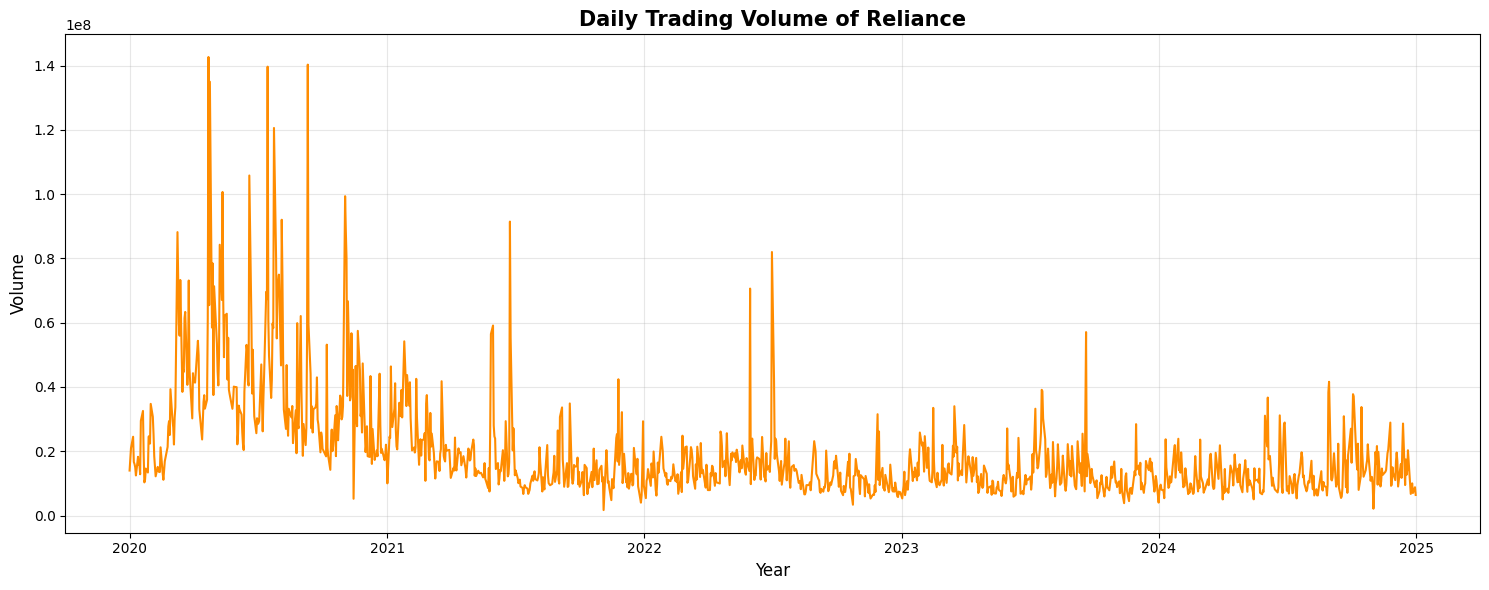

In [13]:
# ==========================================================
# 6.4 TRADING VOLUME ANALYSIS
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    df["date"],
    df["volume"],
    color="darkorange",
    linewidth=1.5
)

plt.title(
    f"Daily Trading Volume of {company}",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Volume", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

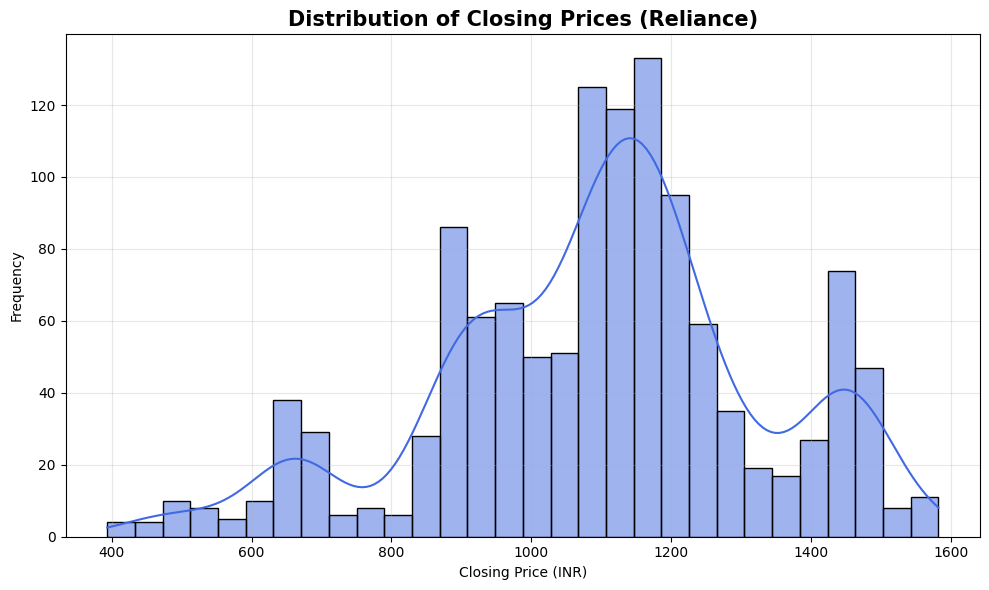

In [14]:
# ==========================================================
# 6.5 DISTRIBUTION OF CLOSING PRICES
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["close"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title(
    f"Distribution of Closing Prices ({company})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Closing Price (INR)")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

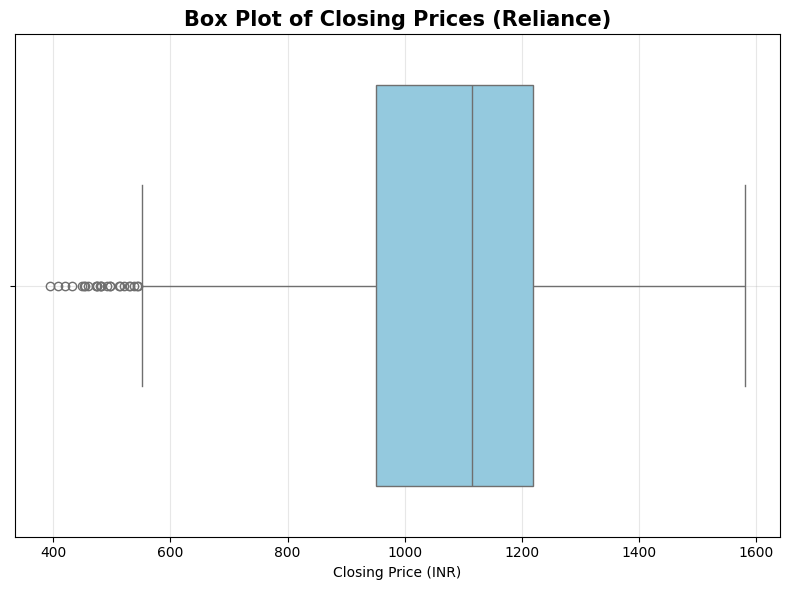

In [15]:
# ==========================================================
# 6.6 BOX PLOT OF CLOSING PRICE
# ==========================================================

plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["close"],
    color="skyblue"
)

plt.title(
    f"Box Plot of Closing Prices ({company})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Closing Price (INR)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

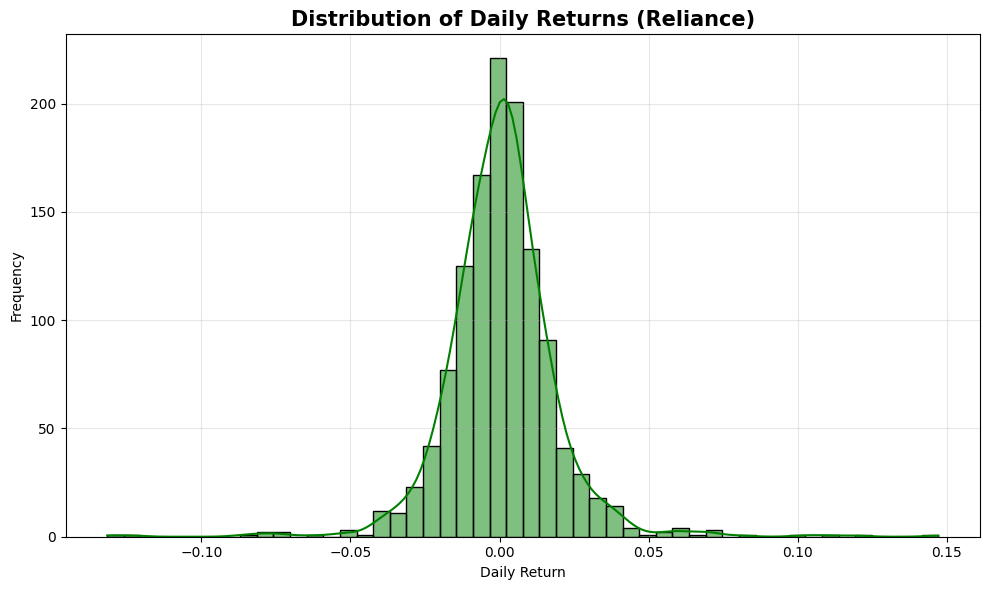

In [16]:
# ==========================================================
# 6.7 DAILY RETURN DISTRIBUTION
# ==========================================================

df["daily_return"] = df["close"].pct_change()

plt.figure(figsize=(10,6))

sns.histplot(
    df["daily_return"].dropna(),
    bins=50,
    kde=True,
    color="green"
)

plt.title(
    f"Distribution of Daily Returns ({company})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

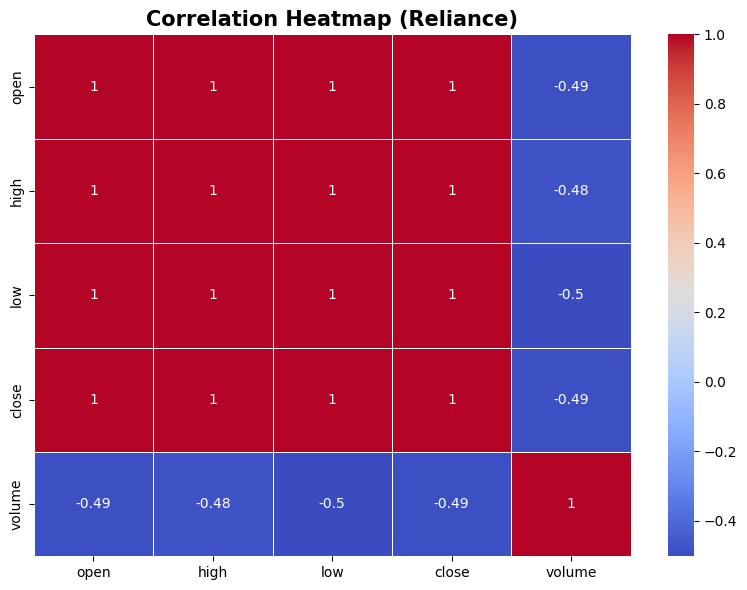

In [17]:
# ==========================================================
# 6.8 CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["open","high","low","close","volume"]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    f"Correlation Heatmap ({company})",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [18]:
# ==========================================================
# 6.9 CANDLESTICK CHART
# ==========================================================

fig = go.Figure(
    data=[
        go.Candlestick(
            x=df["date"],
            open=df["open"],
            high=df["high"],
            low=df["low"],
            close=df["close"]
        )
    ]
)

fig.update_layout(
    title=f"Candlestick Chart of {company}",
    xaxis_title="Date",
    yaxis_title="Price (INR)",
    template="plotly_white",
    height=600
)

fig.show()

## 7. Feature Engineering

Feature engineering is performed to generate technical indicators from the historical stock market data. These indicators capture market trends, momentum, volatility and trading activity, enabling machine learning and deep learning models to learn meaningful patterns for next-day stock movement prediction.

In [19]:
# ==========================================================
# 7.1 PRICE RANGE
# ==========================================================

df["range"] = df["high"] - df["low"]

In [20]:
# ==========================================================
# 7.2 DAILY RETURN
# ==========================================================

df["daily_return"] = df["close"].pct_change()

In [21]:
# ==========================================================
# 7.3 SIMPLE MOVING AVERAGE (20)
# ==========================================================

df["sma_20"] = df["close"].rolling(window=20).mean()

In [22]:
# ==========================================================
# 7.4 EXPONENTIAL MOVING AVERAGE (20)
# ==========================================================

df["ema_20"] = df["close"].ewm(span=20, adjust=False).mean()

In [23]:
# ==========================================================
# 7.5 RELATIVE STRENGTH INDEX
# ==========================================================

delta = df["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["rsi"] = 100 - (100 / (1 + rs))

In [24]:
# ==========================================================
# 7.6 RATE OF CHANGE
# ==========================================================

df["roc"] = df["close"].pct_change(periods=10) * 100

In [25]:
# ==========================================================
# 7.7 BOLLINGER BANDS
# ==========================================================

rolling_mean = df["close"].rolling(20).mean()
rolling_std = df["close"].rolling(20).std()

df["bb_high"] = rolling_mean + (2 * rolling_std)
df["bb_low"] = rolling_mean - (2 * rolling_std)

In [26]:
# ==========================================================
# 7.8 AVERAGE TRUE RANGE
# ==========================================================

high_low = df["high"] - df["low"]

high_close = abs(df["high"] - df["close"].shift())

low_close = abs(df["low"] - df["close"].shift())

true_range = pd.concat(
    [high_low, high_close, low_close],
    axis=1
).max(axis=1)

df["atr"] = true_range.rolling(14).mean()

In [27]:
# ==========================================================
# 7.9 MACD
# ==========================================================

ema12 = df["close"].ewm(span=12, adjust=False).mean()

ema26 = df["close"].ewm(span=26, adjust=False).mean()

df["macd"] = ema12 - ema26

df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()

In [28]:
# ==========================================================
# 7.10 ON BALANCE VOLUME
# ==========================================================

obv = [0]

for i in range(1, len(df)):

    if df["close"].iloc[i] > df["close"].iloc[i-1]:
        obv.append(obv[-1] + df["volume"].iloc[i])

    elif df["close"].iloc[i] < df["close"].iloc[i-1]:
        obv.append(obv[-1] - df["volume"].iloc[i])

    else:
        obv.append(obv[-1])

df["obv"] = obv

In [29]:
df.isna().sum()

date             0
close            0
high             0
low              0
open             0
volume           0
ma50            49
weekday          0
daily_return     1
range            0
sma_20          19
ema_20           0
rsi             14
roc             10
bb_high         19
bb_low          19
atr             13
macd             0
macd_signal      0
obv              0
dtype: int64

In [30]:
# ==========================================================
# 7.11 HANDLE MISSING VALUES
# ==========================================================

df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

In [31]:
df.isna().sum()

date            0
close           0
high            0
low             0
open            0
volume          0
ma50            0
weekday         0
daily_return    0
range           0
sma_20          0
ema_20          0
rsi             0
roc             0
bb_high         0
bb_low          0
atr             0
macd            0
macd_signal     0
obv             0
dtype: int64

In [32]:
df.drop(columns=["ma50","weekday"], inplace=True)

In [33]:
print(df.shape)
df.head()

(1189, 18)


,date,close,high,low,open,volume,daily_return,range,sma_20,ema_20,rsi,roc,bb_high,bb_low,atr,macd,macd_signal,obv
0,2020-03-12,473.347778,490.268953,466.980074,483.144270,55970485.0,-0.078497,23.288879,606.652164,586.782330,11.535746,-23.635046,722.361684,490.942644,27.097741,-37.844748,-23.667103,-359458758.0
1,2020-03-13,492.183746,507.635433,419.645328,444.403667,73297403.0,0.039793,87.990105,598.525545,577.772941,18.143756,-20.266909,722.552984,474.498105,32.613027,-40.554122,-27.044506,-286161355.0
2,2020-03-16,452.285339,480.784159,447.520678,472.256780,38482258.0,-0.081064,33.263481,588.318288,565.821741,16.778861,-23.553980,725.214546,451.422029,34.327417,-45.397475,-30.715100,-324643613.0
3,2020-03-17,448.856567,472.011860,446.719157,466.334342,45445979.0,-0.007581,25.292703,577.640129,554.682200,17.338431,-23.412992,723.239338,432.040920,34.817240,-48.948295,-34.361739,-370089592.0
4,2020-03-18,431.267487,461.280325,427.927786,456.560192,44730415.0,-0.039186,33.352539,566.290695,542.928418,16.929550,-27.877267,720.560233,412.021158,36.275577,-52.575578,-38.004507,-414820007.0


## 8. Target Variable Creation

The target variable is created to classify whether the stock price will increase or decrease on the next trading day. If the next day's closing price is greater than the current day's closing price, the target is assigned a value of 1 (Up); otherwise, it is assigned a value of 0 (Down).

In [34]:
# ==========================================================
# 8. TARGET VARIABLE CREATION
# ==========================================================

# Create Target Variable
df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)

# Remove last row (No next-day target available)
df = df[:-1]

# Check Target Distribution
print(df["target"].value_counts(normalize=True) * 100)

df[["date", "close", "target"]].head()

target
1    52.609428
0    47.390572
Name: proportion, dtype: float64


,date,close,target
0,2020-03-12,473.347778,1
1,2020-03-13,492.183746,0
2,2020-03-16,452.285339,0
3,2020-03-17,448.856567,0
4,2020-03-18,431.267487,0


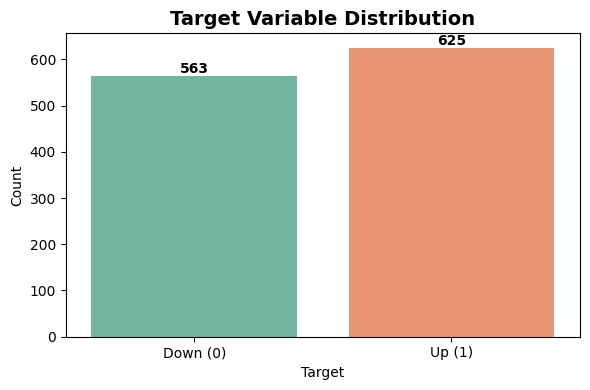

In [35]:
# ==========================================================
# TARGET CLASS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="target",
    data=df,
    palette="Set2"
)

plt.title("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Target")
plt.ylabel("Count")

plt.xticks([0,1], ["Down (0)", "Up (1)"])

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 9. Feature Selection

The most relevant technical indicators were selected as input features for the machine learning and deep learning models. These features represent price movement, trend, momentum, volatility and volume information, while the target variable represents the next-day stock price movement (Up/Down).

In [36]:
# ==========================================================
# 9. FEATURE SELECTION
# ==========================================================

# Input Features
features = [
    "high",
    "low",
    "open",
    "close",
    "volume",
    "range",
    "daily_return",
    "sma_20",
    "ema_20",
    "rsi",
    "roc",
    "bb_high",
    "bb_low",
    "atr",
    "macd",
    "macd_signal",
    "obv"
]

# Independent Variables
X = df[features]

# Target Variable
y = df["target"]

print("Number of Features :", len(features))
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nSelected Features:")
print(features)

Number of Features : 17
Feature Matrix Shape : (1188, 17)
Target Shape : (1188,)

Selected Features:
['high', 'low', 'open', 'close', 'volume', 'range', 'daily_return', 'sma_20', 'ema_20', 'rsi', 'roc', 'bb_high', 'bb_low', 'atr', 'macd', 'macd_signal', 'obv']


In [37]:
print(df.isnull().sum())

date            0
close           0
high            0
low             0
open            0
volume          0
daily_return    0
range           0
sma_20          0
ema_20          0
rsi             0
roc             0
bb_high         0
bb_low          0
atr             0
macd            0
macd_signal     0
obv             0
target          0
dtype: int64


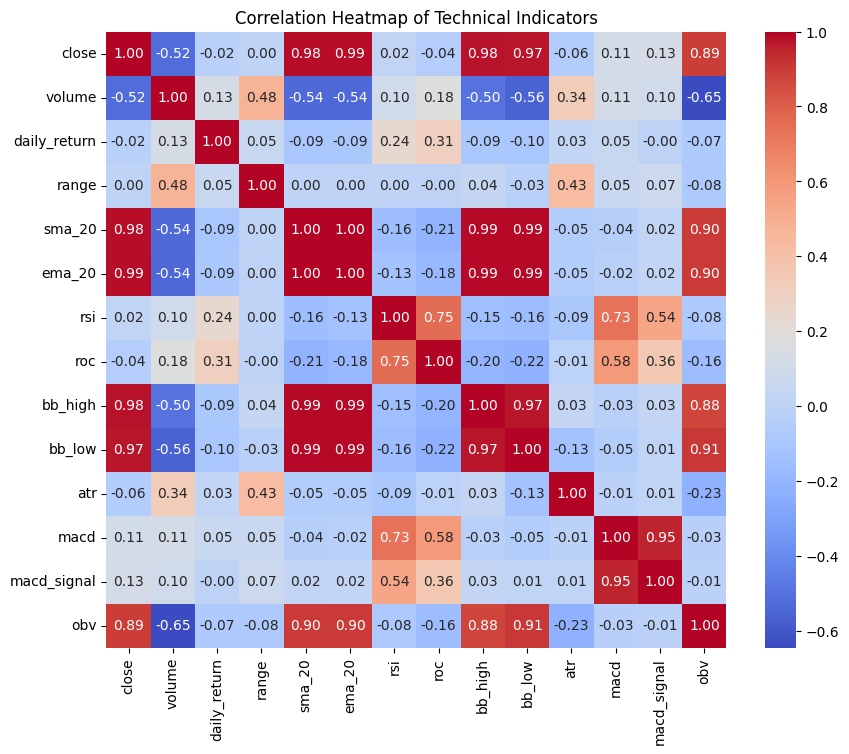

In [38]:
indicator_cols = [
    'close','volume','daily_return','range','sma_20','ema_20','rsi',
    'roc','bb_high','bb_low','atr',
    'macd','macd_signal','obv'
]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[indicator_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap of Technical Indicators")
plt.savefig("correlation_heatmap.png")
plt.show()

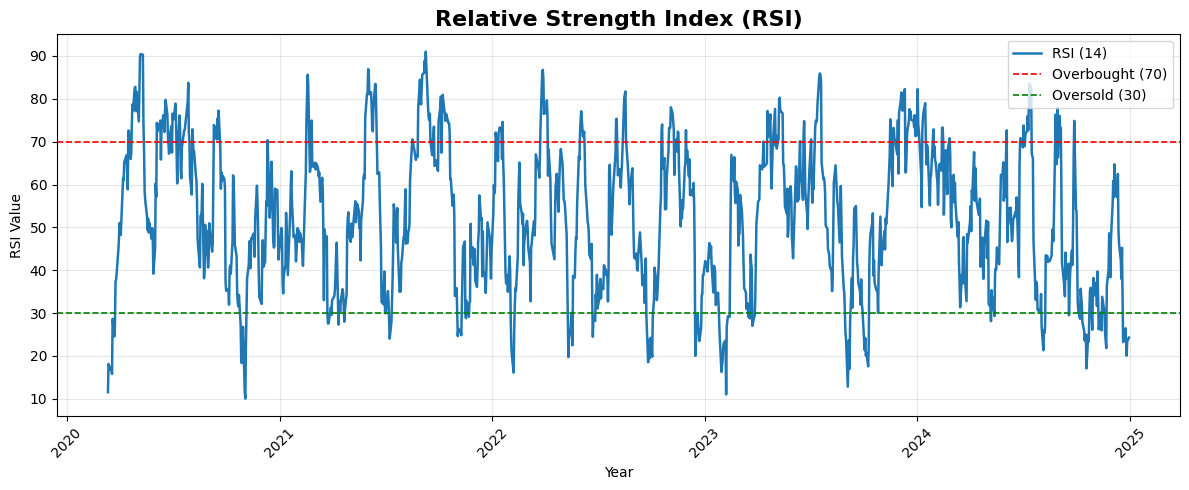

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    df["date"],
    df["rsi"],
    linewidth=1.8,
    label="RSI (14)"
)

ax.axhline(70, color="red", linestyle="--", linewidth=1.2, label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", linewidth=1.2, label="Oversold (30)")

ax.set_title("Relative Strength Index (RSI)", fontsize=16, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("RSI Value")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

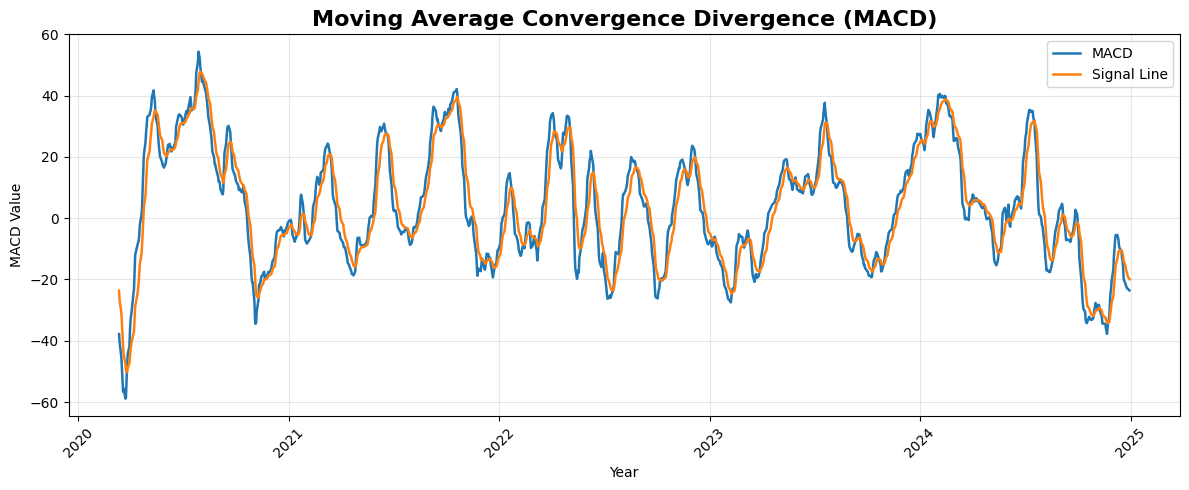

In [40]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    df["date"],
    df["macd"],
    linewidth=1.8,
    label="MACD"
)

ax.plot(
    df["date"],
    df["macd_signal"],
    linewidth=1.8,
    label="Signal Line"
)

ax.set_title("Moving Average Convergence Divergence (MACD)", fontsize=16, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("MACD Value")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

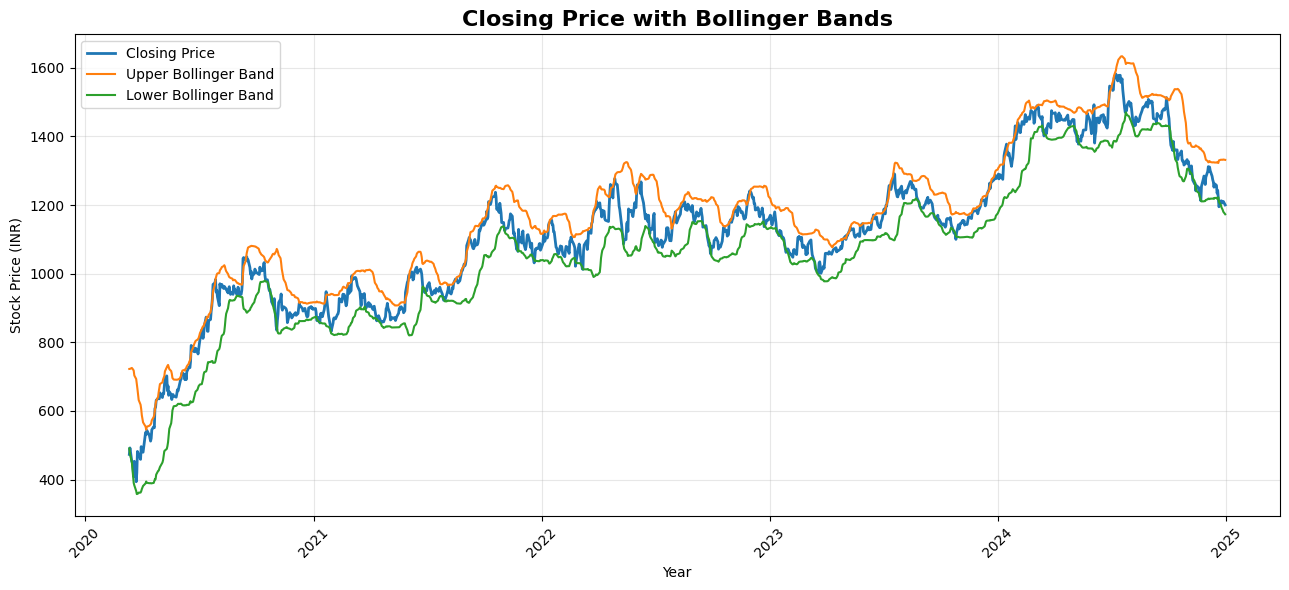

In [41]:
fig, ax = plt.subplots(figsize=(13,6))

ax.plot(
    df["date"],
    df["close"],
    linewidth=2,
    label="Closing Price"
)

ax.plot(
    df["date"],
    df["bb_high"],
    linewidth=1.5,
    label="Upper Bollinger Band"
)

ax.plot(
    df["date"],
    df["bb_low"],
    linewidth=1.5,
    label="Lower Bollinger Band"
)

ax.set_title("Closing Price with Bollinger Bands", fontsize=16, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Stock Price (INR)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

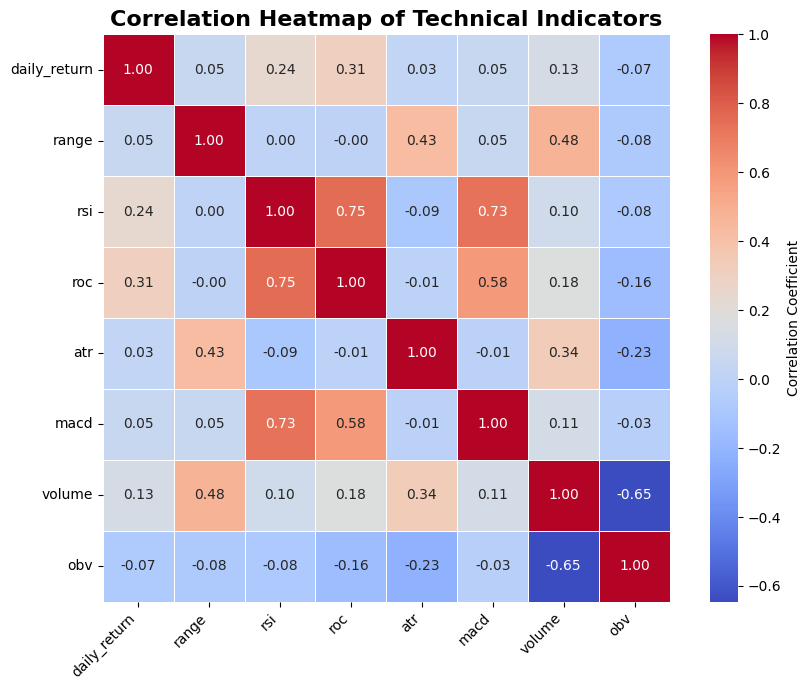

In [42]:
indicator_cols = [
    "daily_return",
    "range",
    "rsi",
    "roc",
    "atr",
    "macd",
    "volume",
    "obv"
]

plt.figure(figsize=(9,7))

sns.heatmap(
    df[indicator_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label":"Correlation Coefficient"}
)

plt.title("Correlation Heatmap of Technical Indicators",
          fontsize=16,
          fontweight="bold")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 10. Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio. Since stock market data is sequential in nature, the data was split chronologically without shuffling to preserve the temporal order and prevent data leakage.

In [43]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'daily_return',
       'range', 'sma_20', 'ema_20', 'rsi', 'roc', 'bb_high', 'bb_low', 'atr',
       'macd', 'macd_signal', 'obv', 'target'],
      dtype='object')

In [44]:
cols = ['close', 'high', 'low', 'open', 'volume', 'daily_return',
       'range', 'sma_20', 'ema_20', 'rsi', 'roc', 'bb_high', 'bb_low', 'atr',
       'macd', 'macd_signal', 'obv']
X = df[cols]
y = df["target"]

In [45]:
# ==========================================================
# 10. TRAIN-TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

# Split dataset (80% Training, 20% Testing)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

print("="*60)
print("Training Set Shape")
print("="*60)
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\n")

print("="*60)
print("Testing Set Shape")
print("="*60)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Training Set Shape
X_train : (950, 17)
y_train : (950,)


Testing Set Shape
X_test : (238, 17)
y_test : (238,)


In [46]:
# ==========================================================
# TRAINING & TESTING DATE RANGE
# ==========================================================

print("Train Start :", df.iloc[X_train.index[0]]["date"])
print("Train End   :", df.iloc[X_train.index[-1]]["date"])

print()

print("Test Start  :", df.iloc[X_test.index[0]]["date"])
print("Test End    :", df.iloc[X_test.index[-1]]["date"])

Train Start : 2020-03-12 00:00:00
Train End   : 2024-01-09 00:00:00

Test Start  : 2024-01-10 00:00:00
Test End    : 2024-12-30 00:00:00


### 11. Random Forest Classifier

In [47]:
# ==========================================================
# 11.1 IMPORT RANDOM FOREST
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

In [48]:
# ==========================================================
# 11.2 BUILD RANDOM FOREST MODEL
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [49]:
# ==========================================================
# 11.3 TRAIN RANDOM FOREST MODEL
# ==========================================================

rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
# ==========================================================
# 11.4 PREDICT TEST DATA
# ==========================================================

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [51]:
# ==========================================================
# 11.5 MODEL EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report\n")

print(classification_report(y_test, rf_pred))

Accuracy : 0.5000
Precision: 0.6250
Recall   : 0.0413
F1 Score : 0.0775

Classification Report

              precision    recall  f1-score   support

           0       0.50      0.97      0.66       117
           1       0.62      0.04      0.08       121

    accuracy                           0.50       238
   macro avg       0.56      0.51      0.37       238
weighted avg       0.56      0.50      0.36       238



### 12. Random Forest Hyperparameter Tuning

Hyperparameter tuning was performed using RandomizedSearchCV with TimeSeriesSplit cross-validation to identify the optimal combination of Random Forest parameters. Since stock market data is sequential, TimeSeriesSplit was used instead of standard K-Fold cross-validation to preserve the chronological order of observations.

In [52]:
# ==========================================================
# 12.1 IMPORT LIBRARIES
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import randint

In [53]:
# ==========================================================
# 12.2 TIME SERIES CROSS VALIDATION
# ==========================================================

tscv = TimeSeriesSplit(n_splits=5)

In [54]:
# ==========================================================
# 12.3 HYPERPARAMETER SEARCH SPACE
# ==========================================================

param_dist = {

    "n_estimators": randint(100, 600),

    "max_depth": [None, 5, 8, 10, 15, 20, 25],

    "min_samples_split": randint(2, 15),

    "min_samples_leaf": randint(1, 8),

    "max_features": ["sqrt", "log2", None],

    "bootstrap": [True, False],

    "criterion": ["gini", "entropy"]

}

In [55]:
# ==========================================================
# 12.4 BASE MODEL
# ==========================================================

rf = RandomForestClassifier(random_state=42)

In [56]:
# ==========================================================
# 12.5 RANDOMIZED SEARCH
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_dist,

    n_iter=25,

    scoring="f1",

    cv=tscv,

    refit=True,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [57]:
# ==========================================================
# 12.6 BEST PARAMETERS
# ==========================================================

print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(random_search.best_params_)

print()

print("="*60)
print("BEST CROSS VALIDATION acc SCORE")
print("="*60)

print(random_search.best_score_)

BEST PARAMETERS
{'bootstrap': False, 'criterion': 'gini', 'max_depth': 25, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 9, 'n_estimators': 392}

BEST CROSS VALIDATION acc SCORE
0.4595457833221423


In [58]:
# ==========================================================
# 12.7 BEST RANDOM FOREST MODEL
# ==========================================================

best_rf = random_search.best_estimator_

In [59]:
# ==========================================================
# 12.8 PREDICTION
# ==========================================================

rf_pred = best_rf.predict(X_test)

rf_prob = best_rf.predict_proba(X_test)[:,1]

In [60]:
# ==========================================================
# 12.9 MODEL EVALUATION
# ==========================================================

from sklearn.metrics import *

accuracy = accuracy_score(y_test, rf_pred)

precision = precision_score(y_test, rf_pred)

recall = recall_score(y_test, rf_pred)

f1 = f1_score(y_test, rf_pred)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

Accuracy : 0.5420
Precision: 0.5309
Recall   : 0.8512
F1 Score : 0.6540

              precision    recall  f1-score   support

           0       0.59      0.22      0.32       117
           1       0.53      0.85      0.65       121

    accuracy                           0.54       238
   macro avg       0.56      0.54      0.49       238
weighted avg       0.56      0.54      0.49       238

[[ 26  91]
 [ 18 103]]


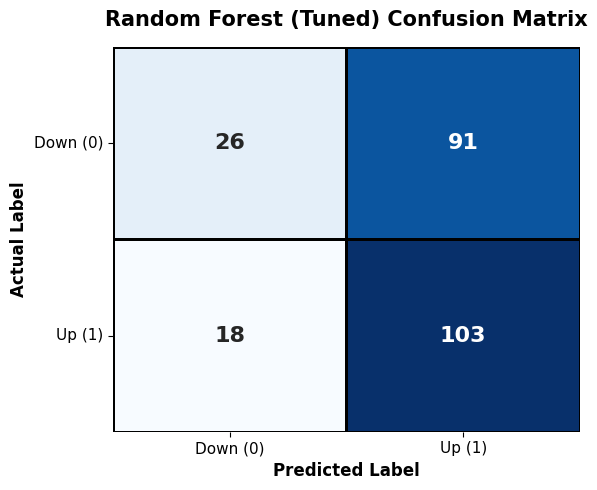

In [61]:
# ==========================================================
# RANDOM FOREST (TUNED) CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="black",
    annot_kws={
        "size":16,
        "weight":"bold"
    },
    xticklabels=["Down (0)", "Up (1)"],
    yticklabels=["Down (0)", "Up (1)"]
)

plt.title(
    "Random Forest (Tuned) Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Label",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

plt.show()

#### Optuna

In [62]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

In [ ]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),
        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy"]
        ),
        "random_state":42,
        "n_jobs":-1
    }

    model = RandomForestClassifier(**params)

    tscv = TimeSeriesSplit(n_splits=5)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [64]:
study = optuna.create_study(
    direction="maximize",
    study_name="RF_Optimization"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-07-16 12:30:49,617] A new study created in memory with name: RF_Optimization
Best trial: 0. Best value: 0.51519:   1%|          | 1/100 [00:01<01:50,  1.12s/it]

[I 2026-07-16 12:30:50,732] Trial 0 finished with value: 0.5151898734177214 and parameters: {'n_estimators': 210, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.5151898734177214.


Best trial: 0. Best value: 0.51519:   2%|▏         | 2/100 [00:02<02:25,  1.49s/it]

[I 2026-07-16 12:30:52,484] Trial 1 finished with value: 0.5050632911392405 and parameters: {'n_estimators': 555, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5151898734177214.


Best trial: 2. Best value: 0.517722:   3%|▎         | 3/100 [00:04<02:50,  1.76s/it]

[I 2026-07-16 12:30:54,563] Trial 2 finished with value: 0.5177215189873418 and parameters: {'n_estimators': 373, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:   4%|▍         | 4/100 [00:06<02:34,  1.61s/it]

[I 2026-07-16 12:30:55,954] Trial 3 finished with value: 0.5151898734177215 and parameters: {'n_estimators': 401, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:   5%|▌         | 5/100 [00:12<05:25,  3.43s/it]

[I 2026-07-16 12:31:02,596] Trial 4 finished with value: 0.5088607594936709 and parameters: {'n_estimators': 389, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:   6%|▌         | 6/100 [00:14<04:26,  2.84s/it]

[I 2026-07-16 12:31:04,297] Trial 5 finished with value: 0.5050632911392405 and parameters: {'n_estimators': 399, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:   7%|▋         | 7/100 [00:17<04:18,  2.78s/it]

[I 2026-07-16 12:31:06,968] Trial 6 finished with value: 0.5075949367088607 and parameters: {'n_estimators': 591, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:   8%|▊         | 8/100 [00:20<04:29,  2.93s/it]

[I 2026-07-16 12:31:10,209] Trial 7 finished with value: 0.5126582278481012 and parameters: {'n_estimators': 411, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:   9%|▉         | 9/100 [00:25<05:14,  3.46s/it]

[I 2026-07-16 12:31:14,808] Trial 8 finished with value: 0.5113924050632911 and parameters: {'n_estimators': 363, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:  10%|█         | 10/100 [00:29<05:30,  3.68s/it]

[I 2026-07-16 12:31:18,987] Trial 9 finished with value: 0.5088607594936708 and parameters: {'n_estimators': 538, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 2. Best value: 0.517722:  11%|█         | 11/100 [00:29<04:00,  2.71s/it]

[I 2026-07-16 12:31:19,504] Trial 10 finished with value: 0.5164556962025316 and parameters: {'n_estimators': 101, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 2 with value: 0.5177215189873418.


Best trial: 11. Best value: 0.518987:  12%|█▏        | 12/100 [00:30<02:59,  2.03s/it]

[I 2026-07-16 12:31:19,998] Trial 11 finished with value: 0.5189873417721518 and parameters: {'n_estimators': 116, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 11 with value: 0.5189873417721518.


Best trial: 12. Best value: 0.521519:  13%|█▎        | 13/100 [00:31<02:27,  1.69s/it]

[I 2026-07-16 12:31:20,908] Trial 12 finished with value: 0.521518987341772 and parameters: {'n_estimators': 251, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 12 with value: 0.521518987341772.


Best trial: 12. Best value: 0.521519:  14%|█▍        | 14/100 [00:31<01:59,  1.39s/it]

[I 2026-07-16 12:31:21,597] Trial 13 finished with value: 0.5189873417721519 and parameters: {'n_estimators': 189, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 12 with value: 0.521518987341772.


Best trial: 12. Best value: 0.521519:  15%|█▌        | 15/100 [00:32<01:45,  1.25s/it]

[I 2026-07-16 12:31:22,507] Trial 14 finished with value: 0.5088607594936708 and parameters: {'n_estimators': 244, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 12 with value: 0.521518987341772.


Best trial: 15. Best value: 0.521519:  16%|█▌        | 16/100 [00:33<01:38,  1.18s/it]

[I 2026-07-16 12:31:23,523] Trial 15 finished with value: 0.5215189873417722 and parameters: {'n_estimators': 262, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  17%|█▋        | 17/100 [00:35<01:36,  1.17s/it]

[I 2026-07-16 12:31:24,665] Trial 16 finished with value: 0.5139240506329114 and parameters: {'n_estimators': 286, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  18%|█▊        | 18/100 [00:36<01:32,  1.13s/it]

[I 2026-07-16 12:31:25,697] Trial 17 finished with value: 0.520253164556962 and parameters: {'n_estimators': 305, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  19%|█▉        | 19/100 [00:36<01:20,  1.01it/s]

[I 2026-07-16 12:31:26,364] Trial 18 finished with value: 0.5050632911392405 and parameters: {'n_estimators': 166, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  20%|██        | 20/100 [00:38<01:37,  1.22s/it]

[I 2026-07-16 12:31:28,144] Trial 19 finished with value: 0.5164556962025315 and parameters: {'n_estimators': 477, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  21%|██        | 21/100 [00:39<01:41,  1.28s/it]

[I 2026-07-16 12:31:29,546] Trial 20 finished with value: 0.5164556962025316 and parameters: {'n_estimators': 312, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  22%|██▏       | 22/100 [00:41<01:42,  1.31s/it]

[I 2026-07-16 12:31:30,931] Trial 21 finished with value: 0.520253164556962 and parameters: {'n_estimators': 296, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  23%|██▎       | 23/100 [00:42<01:45,  1.37s/it]

[I 2026-07-16 12:31:32,421] Trial 22 finished with value: 0.5177215189873418 and parameters: {'n_estimators': 251, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 15. Best value: 0.521519:  24%|██▍       | 24/100 [00:44<01:53,  1.49s/it]

[I 2026-07-16 12:31:34,191] Trial 23 finished with value: 0.5126582278481012 and parameters: {'n_estimators': 327, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 15 with value: 0.5215189873417722.


Best trial: 24. Best value: 0.522785:  25%|██▌       | 25/100 [00:46<01:56,  1.56s/it]

[I 2026-07-16 12:31:35,918] Trial 24 finished with value: 0.5227848101265822 and parameters: {'n_estimators': 260, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 24 with value: 0.5227848101265822.


Best trial: 24. Best value: 0.522785:  26%|██▌       | 26/100 [00:49<02:26,  1.98s/it]

[I 2026-07-16 12:31:38,894] Trial 25 finished with value: 0.5189873417721519 and parameters: {'n_estimators': 243, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 24 with value: 0.5227848101265822.


Best trial: 24. Best value: 0.522785:  27%|██▋       | 27/100 [00:49<01:56,  1.60s/it]

[I 2026-07-16 12:31:39,611] Trial 26 finished with value: 0.5037974683544303 and parameters: {'n_estimators': 161, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 24 with value: 0.5227848101265822.


Best trial: 27. Best value: 0.524051:  28%|██▊       | 28/100 [00:51<01:44,  1.45s/it]

[I 2026-07-16 12:31:40,720] Trial 27 finished with value: 0.5240506329113923 and parameters: {'n_estimators': 219, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 27 with value: 0.5240506329113923.


Best trial: 28. Best value: 0.525316:  29%|██▉       | 29/100 [00:52<01:35,  1.34s/it]

[I 2026-07-16 12:31:41,797] Trial 28 finished with value: 0.5253164556962024 and parameters: {'n_estimators': 216, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 28 with value: 0.5253164556962024.


Best trial: 28. Best value: 0.525316:  30%|███       | 30/100 [00:53<01:29,  1.27s/it]

[I 2026-07-16 12:31:42,909] Trial 29 finished with value: 0.5253164556962024 and parameters: {'n_estimators': 196, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 28 with value: 0.5253164556962024.


Best trial: 30. Best value: 0.53038:  31%|███       | 31/100 [00:54<01:22,  1.20s/it] 

[I 2026-07-16 12:31:43,929] Trial 30 finished with value: 0.530379746835443 and parameters: {'n_estimators': 194, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 30 with value: 0.530379746835443.


Best trial: 30. Best value: 0.53038:  32%|███▏      | 32/100 [00:55<01:25,  1.26s/it]

[I 2026-07-16 12:31:45,347] Trial 31 finished with value: 0.5189873417721519 and parameters: {'n_estimators': 207, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 30 with value: 0.530379746835443.


Best trial: 30. Best value: 0.53038:  33%|███▎      | 33/100 [00:56<01:21,  1.21s/it]

[I 2026-07-16 12:31:46,435] Trial 32 finished with value: 0.521518987341772 and parameters: {'n_estimators': 133, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 30 with value: 0.530379746835443.


Best trial: 30. Best value: 0.53038:  34%|███▍      | 34/100 [00:58<01:24,  1.28s/it]

[I 2026-07-16 12:31:47,880] Trial 33 finished with value: 0.5240506329113924 and parameters: {'n_estimators': 199, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 30 with value: 0.530379746835443.


Best trial: 30. Best value: 0.53038:  35%|███▌      | 35/100 [00:58<01:11,  1.09s/it]

[I 2026-07-16 12:31:48,535] Trial 34 finished with value: 0.5278481012658227 and parameters: {'n_estimators': 159, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 30 with value: 0.530379746835443.


Best trial: 35. Best value: 0.532911:  36%|███▌      | 36/100 [00:59<01:00,  1.06it/s]

[I 2026-07-16 12:31:49,126] Trial 35 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 161, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 35 with value: 0.5329113924050632.


Best trial: 36. Best value: 0.536709:  37%|███▋      | 37/100 [00:59<00:50,  1.24it/s]

[I 2026-07-16 12:31:49,609] Trial 36 finished with value: 0.5367088607594936 and parameters: {'n_estimators': 144, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  38%|███▊      | 38/100 [01:00<00:44,  1.38it/s]

[I 2026-07-16 12:31:50,142] Trial 37 finished with value: 0.5189873417721518 and parameters: {'n_estimators': 146, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  39%|███▉      | 39/100 [01:01<00:46,  1.32it/s]

[I 2026-07-16 12:31:50,977] Trial 38 finished with value: 0.5341772151898734 and parameters: {'n_estimators': 170, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  40%|████      | 40/100 [01:02<00:50,  1.20it/s]

[I 2026-07-16 12:31:51,995] Trial 39 finished with value: 0.5101265822784811 and parameters: {'n_estimators': 125, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  41%|████      | 41/100 [01:03<01:02,  1.05s/it]

[I 2026-07-16 12:31:53,551] Trial 40 finished with value: 0.4848101265822785 and parameters: {'n_estimators': 179, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  42%|████▏     | 42/100 [01:04<00:58,  1.00s/it]

[I 2026-07-16 12:31:54,441] Trial 41 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 152, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  43%|████▎     | 43/100 [01:05<00:57,  1.01s/it]

[I 2026-07-16 12:31:55,470] Trial 42 finished with value: 0.5063291139240507 and parameters: {'n_estimators': 142, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  44%|████▍     | 44/100 [01:06<00:50,  1.12it/s]

[I 2026-07-16 12:31:56,090] Trial 43 finished with value: 0.5341772151898734 and parameters: {'n_estimators': 101, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  45%|████▌     | 45/100 [01:07<00:44,  1.24it/s]

[I 2026-07-16 12:31:56,699] Trial 44 finished with value: 0.5101265822784811 and parameters: {'n_estimators': 104, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  46%|████▌     | 46/100 [01:07<00:43,  1.24it/s]

[I 2026-07-16 12:31:57,499] Trial 45 finished with value: 0.48987341772151904 and parameters: {'n_estimators': 119, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  47%|████▋     | 47/100 [01:09<00:53,  1.01s/it]

[I 2026-07-16 12:31:58,961] Trial 46 finished with value: 0.5101265822784811 and parameters: {'n_estimators': 143, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  48%|████▊     | 48/100 [01:10<00:46,  1.11it/s]

[I 2026-07-16 12:31:59,621] Trial 47 finished with value: 0.5088607594936708 and parameters: {'n_estimators': 101, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  49%|████▉     | 49/100 [01:11<00:53,  1.06s/it]

[I 2026-07-16 12:32:01,042] Trial 48 finished with value: 0.5164556962025316 and parameters: {'n_estimators': 171, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  50%|█████     | 50/100 [01:13<01:00,  1.22s/it]

[I 2026-07-16 12:32:02,634] Trial 49 finished with value: 0.5075949367088608 and parameters: {'n_estimators': 228, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  51%|█████     | 51/100 [01:14<01:01,  1.25s/it]

[I 2026-07-16 12:32:03,938] Trial 50 finished with value: 0.5063291139240507 and parameters: {'n_estimators': 153, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  52%|█████▏    | 52/100 [01:15<00:59,  1.24s/it]

[I 2026-07-16 12:32:05,177] Trial 51 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 176, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  53%|█████▎    | 53/100 [01:16<00:55,  1.18s/it]

[I 2026-07-16 12:32:06,210] Trial 52 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 177, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  54%|█████▍    | 54/100 [01:17<00:50,  1.10s/it]

[I 2026-07-16 12:32:07,121] Trial 53 finished with value: 0.4835443037974684 and parameters: {'n_estimators': 130, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  55%|█████▌    | 55/100 [01:18<00:46,  1.03s/it]

[I 2026-07-16 12:32:07,978] Trial 54 finished with value: 0.5151898734177215 and parameters: {'n_estimators': 115, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  56%|█████▌    | 56/100 [01:19<00:45,  1.03s/it]

[I 2026-07-16 12:32:09,025] Trial 55 finished with value: 0.5341772151898734 and parameters: {'n_estimators': 177, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  57%|█████▋    | 57/100 [01:21<00:54,  1.26s/it]

[I 2026-07-16 12:32:10,803] Trial 56 finished with value: 0.5177215189873418 and parameters: {'n_estimators': 182, 'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  58%|█████▊    | 58/100 [01:22<00:54,  1.31s/it]

[I 2026-07-16 12:32:12,229] Trial 57 finished with value: 0.5202531645569619 and parameters: {'n_estimators': 231, 'max_depth': 4, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  59%|█████▉    | 59/100 [01:24<00:59,  1.44s/it]

[I 2026-07-16 12:32:13,976] Trial 58 finished with value: 0.5126582278481012 and parameters: {'n_estimators': 169, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  60%|██████    | 60/100 [01:26<01:09,  1.75s/it]

[I 2026-07-16 12:32:16,453] Trial 59 finished with value: 0.4886075949367089 and parameters: {'n_estimators': 274, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  61%|██████    | 61/100 [01:29<01:14,  1.91s/it]

[I 2026-07-16 12:32:18,725] Trial 60 finished with value: 0.5012658227848101 and parameters: {'n_estimators': 131, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  62%|██████▏   | 62/100 [01:30<01:03,  1.68s/it]

[I 2026-07-16 12:32:19,893] Trial 61 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 154, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  63%|██████▎   | 63/100 [01:31<00:57,  1.55s/it]

[I 2026-07-16 12:32:21,132] Trial 62 finished with value: 0.5063291139240507 and parameters: {'n_estimators': 114, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  64%|██████▍   | 64/100 [01:33<00:59,  1.64s/it]

[I 2026-07-16 12:32:22,991] Trial 63 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 207, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  65%|██████▌   | 65/100 [01:35<01:00,  1.74s/it]

[I 2026-07-16 12:32:24,961] Trial 64 finished with value: 0.5025316455696203 and parameters: {'n_estimators': 188, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  66%|██████▌   | 66/100 [01:36<00:51,  1.51s/it]

[I 2026-07-16 12:32:25,925] Trial 65 finished with value: 0.5265822784810127 and parameters: {'n_estimators': 146, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  67%|██████▋   | 67/100 [01:40<01:18,  2.37s/it]

[I 2026-07-16 12:32:30,284] Trial 66 finished with value: 0.5278481012658228 and parameters: {'n_estimators': 592, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  68%|██████▊   | 68/100 [01:44<01:32,  2.90s/it]

[I 2026-07-16 12:32:34,437] Trial 67 finished with value: 0.48607594936708864 and parameters: {'n_estimators': 509, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  69%|██████▉   | 69/100 [01:47<01:27,  2.82s/it]

[I 2026-07-16 12:32:37,070] Trial 68 finished with value: 0.5139240506329114 and parameters: {'n_estimators': 165, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  70%|███████   | 70/100 [01:48<01:12,  2.43s/it]

[I 2026-07-16 12:32:38,582] Trial 69 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 231, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  71%|███████   | 71/100 [01:51<01:13,  2.54s/it]

[I 2026-07-16 12:32:41,393] Trial 70 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 422, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  72%|███████▏  | 72/100 [01:56<01:27,  3.13s/it]

[I 2026-07-16 12:32:45,889] Trial 71 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 566, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  73%|███████▎  | 73/100 [01:59<01:28,  3.29s/it]

[I 2026-07-16 12:32:49,547] Trial 72 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 447, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  74%|███████▍  | 74/100 [02:03<01:25,  3.28s/it]

[I 2026-07-16 12:32:52,821] Trial 73 finished with value: 0.4873417721518988 and parameters: {'n_estimators': 378, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  75%|███████▌  | 75/100 [02:06<01:25,  3.40s/it]

[I 2026-07-16 12:32:56,499] Trial 74 finished with value: 0.5025316455696203 and parameters: {'n_estimators': 341, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  76%|███████▌  | 76/100 [02:09<01:16,  3.21s/it]

[I 2026-07-16 12:32:59,250] Trial 75 finished with value: 0.5227848101265822 and parameters: {'n_estimators': 559, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  77%|███████▋  | 77/100 [02:12<01:11,  3.09s/it]

[I 2026-07-16 12:33:02,066] Trial 76 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 425, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  78%|███████▊  | 78/100 [02:16<01:11,  3.24s/it]

[I 2026-07-16 12:33:05,651] Trial 77 finished with value: 0.520253164556962 and parameters: {'n_estimators': 491, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  79%|███████▉  | 79/100 [02:17<00:59,  2.83s/it]

[I 2026-07-16 12:33:07,530] Trial 78 finished with value: 0.5240506329113924 and parameters: {'n_estimators': 549, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  80%|████████  | 80/100 [02:23<01:15,  3.80s/it]

[I 2026-07-16 12:33:13,577] Trial 79 finished with value: 0.48607594936708864 and parameters: {'n_estimators': 567, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  81%|████████  | 81/100 [02:25<00:58,  3.08s/it]

[I 2026-07-16 12:33:14,977] Trial 80 finished with value: 0.5215189873417722 and parameters: {'n_estimators': 349, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  82%|████████▏ | 82/100 [02:28<00:54,  3.04s/it]

[I 2026-07-16 12:33:17,918] Trial 81 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 435, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  83%|████████▎ | 83/100 [02:31<00:52,  3.09s/it]

[I 2026-07-16 12:33:21,133] Trial 82 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 519, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  84%|████████▍ | 84/100 [02:34<00:48,  3.02s/it]

[I 2026-07-16 12:33:23,974] Trial 83 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 399, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  85%|████████▌ | 85/100 [02:37<00:45,  3.05s/it]

[I 2026-07-16 12:33:27,094] Trial 84 finished with value: 0.4886075949367089 and parameters: {'n_estimators': 422, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  86%|████████▌ | 86/100 [02:40<00:43,  3.08s/it]

[I 2026-07-16 12:33:30,239] Trial 85 finished with value: 0.48607594936708864 and parameters: {'n_estimators': 454, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  87%|████████▋ | 87/100 [02:44<00:44,  3.45s/it]

[I 2026-07-16 12:33:34,577] Trial 86 finished with value: 0.5075949367088608 and parameters: {'n_estimators': 574, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  88%|████████▊ | 88/100 [02:45<00:30,  2.56s/it]

[I 2026-07-16 12:33:35,048] Trial 87 finished with value: 0.5215189873417722 and parameters: {'n_estimators': 137, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  89%|████████▉ | 89/100 [02:47<00:25,  2.30s/it]

[I 2026-07-16 12:33:36,757] Trial 88 finished with value: 0.5240506329113923 and parameters: {'n_estimators': 524, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  90%|█████████ | 90/100 [02:47<00:18,  1.81s/it]

[I 2026-07-16 12:33:37,416] Trial 89 finished with value: 0.5075949367088607 and parameters: {'n_estimators': 110, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  91%|█████████ | 91/100 [02:52<00:22,  2.54s/it]

[I 2026-07-16 12:33:41,629] Trial 90 finished with value: 0.5075949367088608 and parameters: {'n_estimators': 465, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  92%|█████████▏| 92/100 [02:54<00:20,  2.61s/it]

[I 2026-07-16 12:33:44,434] Trial 91 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 429, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  93%|█████████▎| 93/100 [02:57<00:18,  2.67s/it]

[I 2026-07-16 12:33:47,223] Trial 92 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 413, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  94%|█████████▍| 94/100 [02:59<00:15,  2.57s/it]

[I 2026-07-16 12:33:49,585] Trial 93 finished with value: 0.4886075949367089 and parameters: {'n_estimators': 383, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  95%|█████████▌| 95/100 [03:02<00:13,  2.63s/it]

[I 2026-07-16 12:33:52,344] Trial 94 finished with value: 0.5329113924050632 and parameters: {'n_estimators': 485, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  96%|█████████▌| 96/100 [03:05<00:10,  2.54s/it]

[I 2026-07-16 12:33:54,677] Trial 95 finished with value: 0.48607594936708864 and parameters: {'n_estimators': 324, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  97%|█████████▋| 97/100 [03:06<00:06,  2.25s/it]

[I 2026-07-16 12:33:56,266] Trial 96 finished with value: 0.5164556962025316 and parameters: {'n_estimators': 436, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  98%|█████████▊| 98/100 [03:09<00:04,  2.39s/it]

[I 2026-07-16 12:33:58,972] Trial 97 finished with value: 0.48607594936708864 and parameters: {'n_estimators': 401, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709:  99%|█████████▉| 99/100 [03:12<00:02,  2.49s/it]

[I 2026-07-16 12:34:01,683] Trial 98 finished with value: 0.5316455696202531 and parameters: {'n_estimators': 367, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


Best trial: 36. Best value: 0.536709: 100%|██████████| 100/100 [03:12<00:00,  1.93s/it]

[I 2026-07-16 12:34:02,236] Trial 99 finished with value: 0.5189873417721519 and parameters: {'n_estimators': 125, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 36 with value: 0.5367088607594936.


In [65]:
print("Best Accuracy:", study.best_value)
print()

print("Best Parameters")

for k,v in study.best_params.items():
    print(f"{k}: {v}")

Best Accuracy: 0.5367088607594936

Best Parameters
n_estimators: 144
max_depth: 4
min_samples_split: 6
min_samples_leaf: 3
max_features: sqrt
bootstrap: False
criterion: gini


In [66]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

,n_estimators,144
,criterion,'gini'
,max_depth,4
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [67]:
y_pred = best_rf.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.5
Precision: 0.6666666666666666
Recall   : 0.03305785123966942
F1 Score : 0.06299212598425197


In [69]:
import pandas as pd

best_params = pd.DataFrame(
    study.best_params.items(),
    columns=["Parameter","Value"]
)

print(best_params)

           Parameter  Value
0       n_estimators    144
1          max_depth      4
2  min_samples_split      6
3   min_samples_leaf      3
4       max_features   sqrt
5          bootstrap  False
6          criterion   gini


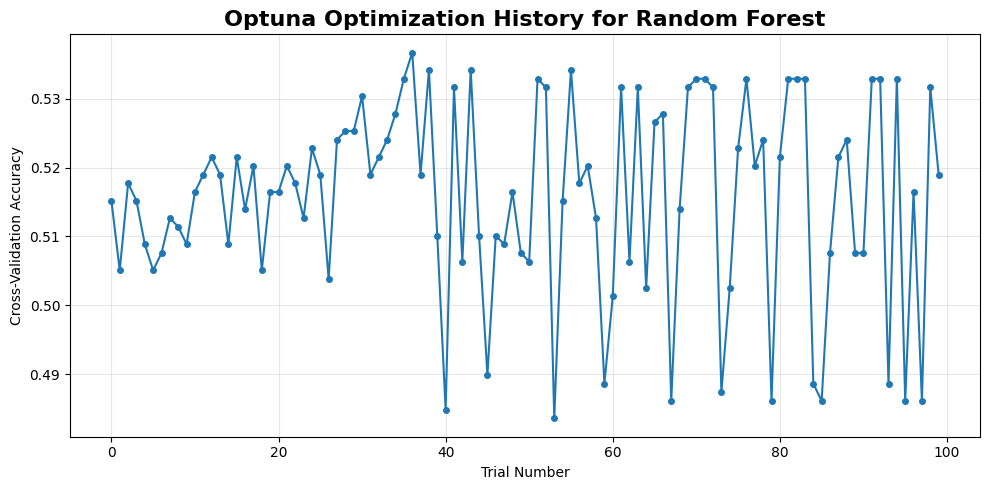

In [70]:
import matplotlib.pyplot as plt

trial_numbers = [trial.number for trial in study.trials]
scores = [trial.value for trial in study.trials]

plt.figure(figsize=(10,5))

plt.plot(
    trial_numbers,
    scores,
    marker='o',
    linewidth=1.5,
    markersize=4
)

plt.title("Optuna Optimization History for Random Forest",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Trial Number")
plt.ylabel("Cross-Validation Accuracy")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

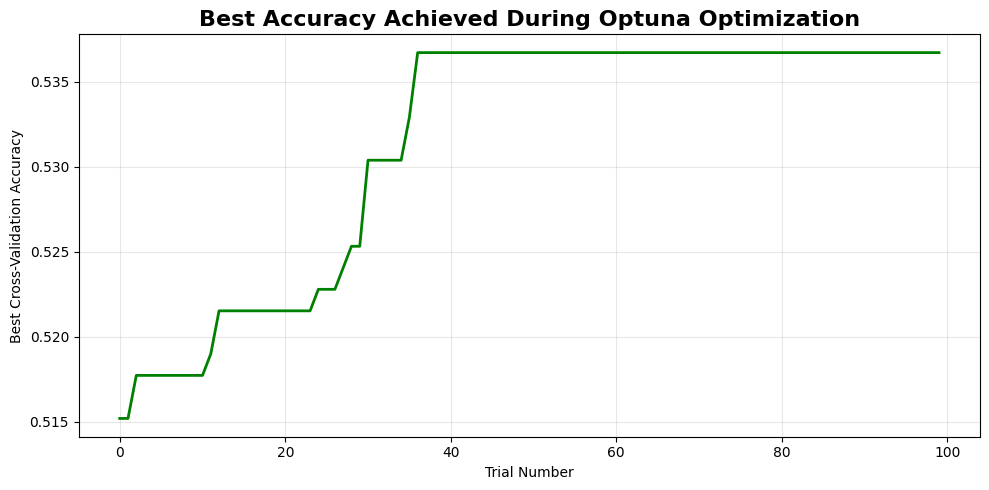

In [71]:
import numpy as np

best_scores = np.maximum.accumulate(scores)

plt.figure(figsize=(10,5))

plt.plot(
    trial_numbers,
    best_scores,
    linewidth=2,
    color='green'
)

plt.title("Best Accuracy Achieved During Optuna Optimization",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Trial Number")
plt.ylabel("Best Cross-Validation Accuracy")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

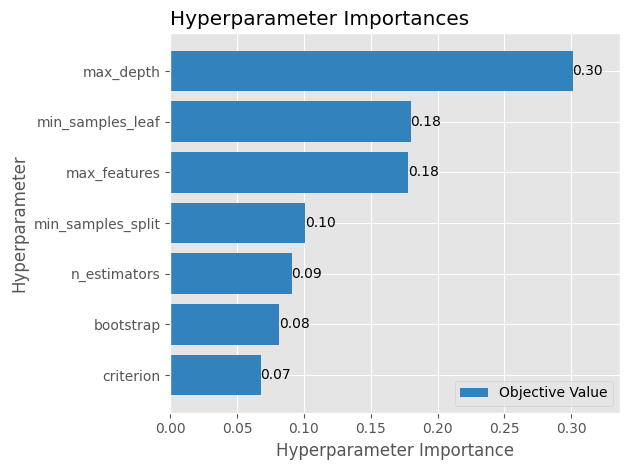

In [72]:
from optuna.visualization.matplotlib import plot_param_importances

plot_param_importances(study)

plt.tight_layout()
plt.show()

### 13. XGBoost Model

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that builds multiple decision trees sequentially. Each new tree attempts to correct the errors made by the previous trees, making XGBoost one of the most powerful algorithms for classification and prediction tasks.

In [73]:
# ==========================================================
# 13.1 IMPORT XGBOOST
# ==========================================================

from xgboost import XGBClassifier

In [74]:
# ==========================================================
# 13.2 BUILD XGBOOST MODEL
# ==========================================================

xgb_model = XGBClassifier(

    objective="binary:logistic",

    n_estimators=100,

    learning_rate=0.1,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

In [75]:
# ==========================================================
# 13.3 TRAIN XGBOOST MODEL
# ==========================================================

xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [76]:
# ==========================================================
# 13.4 PREDICTION
# ==========================================================

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [77]:
# ==========================================================
# 13.5 MODEL EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, xgb_pred)

precision = precision_score(y_test, xgb_pred)

recall = recall_score(y_test, xgb_pred)

f1 = f1_score(y_test, xgb_pred)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))

Accuracy : 0.5000
Precision: 0.5238
Recall   : 0.1818
F1 Score : 0.2699

              precision    recall  f1-score   support

           0       0.49      0.83      0.62       117
           1       0.52      0.18      0.27       121

    accuracy                           0.50       238
   macro avg       0.51      0.51      0.44       238
weighted avg       0.51      0.50      0.44       238

[[97 20]
 [99 22]]


### 14. XGBoost Hyperparameter Tuning

Hyperparameter tuning was performed using RandomizedSearchCV with TimeSeriesSplit cross-validation to identify the optimal XGBoost parameters. The F1-score was selected as the optimization metric because it provides a balanced evaluation of precision and recall for binary classification.

In [78]:
# ==========================================================
# 14.1 IMPORT LIBRARIES
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import randint, uniform

In [79]:
# ==========================================================
# 14.2 TIME SERIES CROSS VALIDATION
# ==========================================================

tscv = TimeSeriesSplit(n_splits=5)

In [80]:
# # ==========================================================
# # 14.3 HYPERPARAMETER SEARCH SPACE
# # ==========================================================

# param_dist = {

#     "n_estimators": randint(100, 600),

#     "max_depth": randint(3, 10),

#     "learning_rate": uniform(0.01, 0.29),

#     "subsample": uniform(0.6, 0.4),

#     "colsample_bytree": uniform(0.6, 0.4),

#     "min_child_weight": randint(1, 10),

#     "gamma": uniform(0, 0.5)

# }

In [81]:
from scipy.stats import randint

param_dist = {

    "n_estimators": [100, 150, 200, 250, 300],

    "max_depth": [3, 4, 5, 6],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.05, 0.1]
}

In [82]:
# ==========================================================
# 14.4 BASE MODEL
# ==========================================================

xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42
)

In [83]:
# ==========================================================
# 14.5 RANDOMIZED SEARCH
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_dist,

    n_iter=50,

    scoring="balanced_accuracy",

    cv=tscv,

    refit=True,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.05, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,50
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [84]:
# ==========================================================
# 14.6 BEST PARAMETERS
# ==========================================================

print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(random_search.best_params_)


print()

print("="*60)
print("BEST CROSS VALIDATION acc SCORE")
print("="*60)

print(random_search.best_score_)

BEST PARAMETERS
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.05, 'colsample_bytree': 0.8}

BEST CROSS VALIDATION acc SCORE
0.5504718227275206


In [85]:
# ==========================================================
# 14.7 BEST MODEL
# ==========================================================

best_xgb = random_search.best_estimator_

In [86]:
# ==========================================================
# 14.8 PREDICTION
# ==========================================================

xgb_pred = best_xgb.predict(X_test)

xgb_prob = best_xgb.predict_proba(X_test)[:,1]

In [87]:
# ==========================================================
# 14.9 MODEL EVALUATION
# ==========================================================

from sklearn.metrics import *

accuracy = accuracy_score(y_test, xgb_pred)

precision = precision_score(y_test, xgb_pred)

recall = recall_score(y_test, xgb_pred)

f1 = f1_score(y_test, xgb_pred)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

Accuracy : 0.5378
Precision: 0.5965
Recall   : 0.2810
F1 Score : 0.3820

              precision    recall  f1-score   support

           0       0.52      0.80      0.63       117
           1       0.60      0.28      0.38       121

    accuracy                           0.54       238
   macro avg       0.56      0.54      0.51       238
weighted avg       0.56      0.54      0.50       238

[[94 23]
 [87 34]]


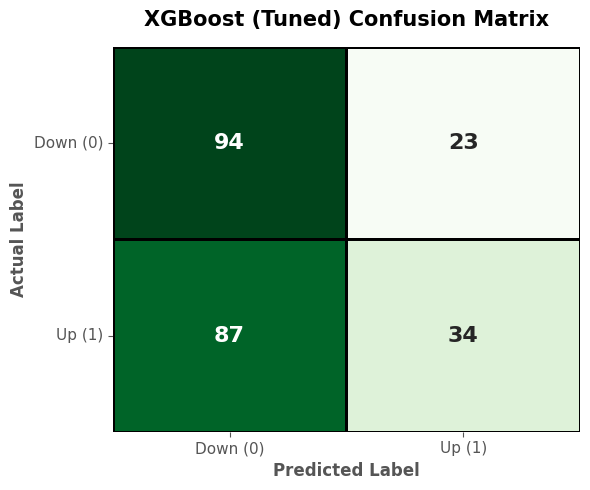

In [88]:
# ==========================================================
# XGBOOST (TUNED) CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    linewidths=1,
    linecolor="black",
    annot_kws={
        "size":16,
        "weight":"bold"
    },
    xticklabels=["Down (0)", "Up (1)"],
    yticklabels=["Down (0)", "Up (1)"]
)

plt.title(
    "XGBoost (Tuned) Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Label",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

plt.show()

In [89]:
import optuna
import xgboost as xgb

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

In [90]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 800),

        "max_depth": trial.suggest_int("max_depth", 3, 12),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10,
            log=True
        ),

        "objective": "binary:logistic",

        "eval_metric": "logloss",

        "tree_method": "hist",

        "device": "cuda",

        "random_state": 42,

        "verbosity": 0
    }

    model = xgb.XGBClassifier(**params)

    tscv = TimeSeriesSplit(n_splits=5)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="balanced_accuracy",
        n_jobs=1     # keep as 1 for GPU
    ).mean()

    return score

In [91]:
study = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_CUDA_Optimization"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-07-16 12:34:38,673] A new study created in memory with name: XGBoost_CUDA_Optimization
Best trial: 0. Best value: 0.524922:   1%|          | 1/100 [00:08<14:14,  8.63s/it]

[I 2026-07-16 12:34:47,308] Trial 0 finished with value: 0.5249220960067695 and parameters: {'n_estimators': 705, 'max_depth': 8, 'learning_rate': 0.053903160728067535, 'subsample': 0.675908858795832, 'colsample_bytree': 0.9250440242245153, 'gamma': 3.1940274274862817, 'min_child_weight': 3, 'reg_alpha': 3.9065334566987326, 'reg_lambda': 0.15210623671007173}. Best is trial 0 with value: 0.5249220960067695.


Best trial: 1. Best value: 0.531475:   2%|▏         | 2/100 [00:14<10:58,  6.72s/it]

[I 2026-07-16 12:34:52,694] Trial 1 finished with value: 0.5314751221897546 and parameters: {'n_estimators': 483, 'max_depth': 5, 'learning_rate': 0.09343378293254832, 'subsample': 0.8157534460925877, 'colsample_bytree': 0.7798651678626496, 'gamma': 2.171720168350581, 'min_child_weight': 1, 'reg_alpha': 0.0034530708350109757, 'reg_lambda': 0.15491086269194948}. Best is trial 1 with value: 0.5314751221897546.


Best trial: 1. Best value: 0.531475:   3%|▎         | 3/100 [00:19<09:43,  6.02s/it]

[I 2026-07-16 12:34:57,866] Trial 2 finished with value: 0.5071867926959104 and parameters: {'n_estimators': 407, 'max_depth': 8, 'learning_rate': 0.07343417114073618, 'subsample': 0.6770173349084274, 'colsample_bytree': 0.6858376897928288, 'gamma': 2.173656883804573, 'min_child_weight': 7, 'reg_alpha': 2.0929497873603285e-05, 'reg_lambda': 0.0012988392211724436}. Best is trial 1 with value: 0.5314751221897546.


Best trial: 1. Best value: 0.531475:   4%|▍         | 4/100 [00:20<06:54,  4.32s/it]

[I 2026-07-16 12:34:59,582] Trial 3 finished with value: 0.5252086949578102 and parameters: {'n_estimators': 136, 'max_depth': 3, 'learning_rate': 0.014987255442993308, 'subsample': 0.9346426364499181, 'colsample_bytree': 0.7522053920181196, 'gamma': 4.549663591221421, 'min_child_weight': 8, 'reg_alpha': 1.1748629852434042e-05, 'reg_lambda': 0.22921812128612623}. Best is trial 1 with value: 0.5314751221897546.


Best trial: 4. Best value: 0.541987:   5%|▌         | 5/100 [00:31<10:25,  6.59s/it]

[I 2026-07-16 12:35:10,191] Trial 4 finished with value: 0.541986584146151 and parameters: {'n_estimators': 475, 'max_depth': 8, 'learning_rate': 0.12406579232888933, 'subsample': 0.6570049451854304, 'colsample_bytree': 0.9979656839939803, 'gamma': 0.16413690607226195, 'min_child_weight': 7, 'reg_alpha': 0.01702206427075261, 'reg_lambda': 0.008414500803917455}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:   6%|▌         | 6/100 [00:35<08:48,  5.62s/it]

[I 2026-07-16 12:35:13,941] Trial 5 finished with value: 0.534132508380156 and parameters: {'n_estimators': 336, 'max_depth': 3, 'learning_rate': 0.08228715394585231, 'subsample': 0.6064199529729511, 'colsample_bytree': 0.6560328349785297, 'gamma': 4.233699648149943, 'min_child_weight': 9, 'reg_alpha': 0.012233682212020622, 'reg_lambda': 0.0007481560298431304}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:   7%|▋         | 7/100 [00:40<08:44,  5.64s/it]

[I 2026-07-16 12:35:19,607] Trial 6 finished with value: 0.5215387458371463 and parameters: {'n_estimators': 564, 'max_depth': 4, 'learning_rate': 0.19047444062935887, 'subsample': 0.79782373031469, 'colsample_bytree': 0.7543702303275468, 'gamma': 0.8659859916126189, 'min_child_weight': 9, 'reg_alpha': 9.601620479176912, 'reg_lambda': 0.007639611983344149}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:   8%|▊         | 8/100 [00:45<08:03,  5.26s/it]

[I 2026-07-16 12:35:24,047] Trial 7 finished with value: 0.5273000839144635 and parameters: {'n_estimators': 215, 'max_depth': 10, 'learning_rate': 0.010147441668436903, 'subsample': 0.8606331187408185, 'colsample_bytree': 0.9168546608398328, 'gamma': 2.062399360109328, 'min_child_weight': 8, 'reg_alpha': 0.11722070102303463, 'reg_lambda': 6.3494293249217675}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:   9%|▉         | 9/100 [00:50<07:47,  5.14s/it]

[I 2026-07-16 12:35:28,927] Trial 8 finished with value: 0.5309512226538065 and parameters: {'n_estimators': 181, 'max_depth': 11, 'learning_rate': 0.06016551077465263, 'subsample': 0.759770926643667, 'colsample_bytree': 0.9872734095613841, 'gamma': 0.5353731050020061, 'min_child_weight': 3, 'reg_alpha': 0.17491258077246968, 'reg_lambda': 4.7362811757640414e-05}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  10%|█         | 10/100 [01:06<12:41,  8.46s/it]

[I 2026-07-16 12:35:44,834] Trial 9 finished with value: 0.5268580436114 and parameters: {'n_estimators': 674, 'max_depth': 11, 'learning_rate': 0.02543454602003069, 'subsample': 0.6332395988154836, 'colsample_bytree': 0.6875154657528513, 'gamma': 0.687330050896266, 'min_child_weight': 8, 'reg_alpha': 4.5461685607064195e-05, 'reg_lambda': 0.006586048732440451}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  11%|█         | 11/100 [01:14<12:20,  8.32s/it]

[I 2026-07-16 12:35:52,823] Trial 10 finished with value: 0.513386628290465 and parameters: {'n_estimators': 771, 'max_depth': 6, 'learning_rate': 0.25238961591979847, 'subsample': 0.9964039923418162, 'colsample_bytree': 0.8360375992987906, 'gamma': 3.2744395979880307, 'min_child_weight': 5, 'reg_alpha': 0.0005462207261410084, 'reg_lambda': 8.625847584209515}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  12%|█▏        | 12/100 [01:19<10:56,  7.46s/it]

[I 2026-07-16 12:35:58,329] Trial 11 finished with value: 0.5276505957048534 and parameters: {'n_estimators': 345, 'max_depth': 7, 'learning_rate': 0.15124609217165702, 'subsample': 0.6048163529551844, 'colsample_bytree': 0.6137465410002657, 'gamma': 4.627641974397014, 'min_child_weight': 10, 'reg_alpha': 0.01146463678868386, 'reg_lambda': 0.00012488826600244888}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  13%|█▎        | 13/100 [01:26<10:30,  7.24s/it]

[I 2026-07-16 12:36:05,065] Trial 12 finished with value: 0.5285853642578372 and parameters: {'n_estimators': 299, 'max_depth': 9, 'learning_rate': 0.11603489507928497, 'subsample': 0.7179951616731604, 'colsample_bytree': 0.6015533082961676, 'gamma': 0.023118289706665962, 'min_child_weight': 6, 'reg_alpha': 0.04323770413176384, 'reg_lambda': 0.0007586091222032376}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  14%|█▍        | 14/100 [01:32<09:50,  6.87s/it]

[I 2026-07-16 12:36:11,061] Trial 13 finished with value: 0.533920339208583 and parameters: {'n_estimators': 524, 'max_depth': 3, 'learning_rate': 0.04058448309116403, 'subsample': 0.6602706950831272, 'colsample_bytree': 0.8659569800167926, 'gamma': 3.7306277280181694, 'min_child_weight': 10, 'reg_alpha': 0.0005493405542865439, 'reg_lambda': 0.00885634173154532}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  15%|█▌        | 15/100 [01:41<10:33,  7.45s/it]

[I 2026-07-16 12:36:19,881] Trial 14 finished with value: 0.5134753819392464 and parameters: {'n_estimators': 399, 'max_depth': 5, 'learning_rate': 0.037509022628820894, 'subsample': 0.6020220226423039, 'colsample_bytree': 0.9557278933824528, 'gamma': 1.4452027512232284, 'min_child_weight': 6, 'reg_alpha': 0.7011994063050188, 'reg_lambda': 1.0310307105360003e-05}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  16%|█▌        | 16/100 [01:44<08:40,  6.20s/it]

[I 2026-07-16 12:36:23,163] Trial 15 finished with value: 0.5122177528587183 and parameters: {'n_estimators': 272, 'max_depth': 12, 'learning_rate': 0.12111086299965919, 'subsample': 0.7156132012468827, 'colsample_bytree': 0.84270741609122, 'gamma': 3.92042397914111, 'min_child_weight': 6, 'reg_alpha': 0.007149313516426418, 'reg_lambda': 0.0005387310487679339}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  17%|█▋        | 17/100 [01:53<09:43,  7.03s/it]

[I 2026-07-16 12:36:32,109] Trial 16 finished with value: 0.5261906463119279 and parameters: {'n_estimators': 606, 'max_depth': 6, 'learning_rate': 0.21998847701963462, 'subsample': 0.7172409876159197, 'colsample_bytree': 0.6966959504336778, 'gamma': 2.8490941649249475, 'min_child_weight': 4, 'reg_alpha': 0.001428074887144464, 'reg_lambda': 0.030834368811474704}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  18%|█▊        | 18/100 [01:58<08:59,  6.57s/it]

[I 2026-07-16 12:36:37,635] Trial 17 finished with value: 0.5217640420796841 and parameters: {'n_estimators': 449, 'max_depth': 8, 'learning_rate': 0.09005471713304333, 'subsample': 0.6492690141045727, 'colsample_bytree': 0.8015732556150081, 'gamma': 4.978101393353629, 'min_child_weight': 9, 'reg_alpha': 0.03736376548301949, 'reg_lambda': 0.0001825976049767444}. Best is trial 4 with value: 0.541986584146151.


Best trial: 4. Best value: 0.541987:  19%|█▉        | 19/100 [02:05<09:01,  6.68s/it]

[I 2026-07-16 12:36:44,569] Trial 18 finished with value: 0.5224494493706818 and parameters: {'n_estimators': 344, 'max_depth': 4, 'learning_rate': 0.2954785976002717, 'subsample': 0.756328923180457, 'colsample_bytree': 0.8945810357464072, 'gamma': 1.249984569727689, 'min_child_weight': 7, 'reg_alpha': 0.00020986737905925252, 'reg_lambda': 0.002535396649871504}. Best is trial 4 with value: 0.541986584146151.


Best trial: 19. Best value: 0.548118:  20%|██        | 20/100 [02:17<11:01,  8.27s/it]

[I 2026-07-16 12:36:56,549] Trial 19 finished with value: 0.5481183564770492 and parameters: {'n_estimators': 472, 'max_depth': 9, 'learning_rate': 0.14447688547095625, 'subsample': 0.6266069025202019, 'colsample_bytree': 0.9999303965271786, 'gamma': 0.0292295021398003, 'min_child_weight': 9, 'reg_alpha': 0.7949079202732825, 'reg_lambda': 0.04307766494999561}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 19. Best value: 0.548118:  21%|██        | 21/100 [02:30<12:28,  9.47s/it]

[I 2026-07-16 12:37:08,811] Trial 20 finished with value: 0.5397030772311078 and parameters: {'n_estimators': 631, 'max_depth': 9, 'learning_rate': 0.158915710288089, 'subsample': 0.6944517890917086, 'colsample_bytree': 0.9861155735840172, 'gamma': 0.09961752356225602, 'min_child_weight': 7, 'reg_alpha': 1.560551433619115, 'reg_lambda': 1.3705031971647252}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 19. Best value: 0.548118:  22%|██▏       | 22/100 [02:42<13:29, 10.38s/it]

[I 2026-07-16 12:37:21,304] Trial 21 finished with value: 0.5397136042016637 and parameters: {'n_estimators': 621, 'max_depth': 9, 'learning_rate': 0.13303698616217013, 'subsample': 0.7052546095889592, 'colsample_bytree': 0.9930019480550513, 'gamma': 0.10572327318402362, 'min_child_weight': 7, 'reg_alpha': 1.0925297147949666, 'reg_lambda': 1.1184128182876032}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 19. Best value: 0.548118:  23%|██▎       | 23/100 [02:55<14:25, 11.23s/it]

[I 2026-07-16 12:37:34,538] Trial 22 finished with value: 0.5334550060033239 and parameters: {'n_estimators': 539, 'max_depth': 9, 'learning_rate': 0.12546373921932313, 'subsample': 0.7500036830640986, 'colsample_bytree': 0.9554512055529858, 'gamma': 0.3420900104226964, 'min_child_weight': 8, 'reg_alpha': 0.44255456401190935, 'reg_lambda': 0.03999303818841801}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 19. Best value: 0.548118:  24%|██▍       | 24/100 [03:02<12:39, 10.00s/it]

[I 2026-07-16 12:37:41,641] Trial 23 finished with value: 0.523079212934328 and parameters: {'n_estimators': 475, 'max_depth': 10, 'learning_rate': 0.1773912186488653, 'subsample': 0.6423441158754568, 'colsample_bytree': 0.9942819109293913, 'gamma': 1.006625072285227, 'min_child_weight': 5, 'reg_alpha': 1.8282092978791131, 'reg_lambda': 1.1865448016513265}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 19. Best value: 0.548118:  25%|██▌       | 25/100 [03:11<11:56,  9.56s/it]

[I 2026-07-16 12:37:50,179] Trial 24 finished with value: 0.52569536035514 and parameters: {'n_estimators': 591, 'max_depth': 7, 'learning_rate': 0.11108194375537661, 'subsample': 0.6964163421874482, 'colsample_bytree': 0.952928223733682, 'gamma': 1.5059269305611207, 'min_child_weight': 7, 'reg_alpha': 0.19941722021258465, 'reg_lambda': 0.03633013625025938}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 19. Best value: 0.548118:  26%|██▌       | 26/100 [03:26<13:44, 11.14s/it]

[I 2026-07-16 12:38:05,006] Trial 25 finished with value: 0.5452563862639537 and parameters: {'n_estimators': 793, 'max_depth': 10, 'learning_rate': 0.14840411949884408, 'subsample': 0.6319877787794861, 'colsample_bytree': 0.9980113416612117, 'gamma': 0.38326076572932855, 'min_child_weight': 9, 'reg_alpha': 0.034624327865712755, 'reg_lambda': 0.9032600753984433}. Best is trial 19 with value: 0.5481183564770492.


Best trial: 26. Best value: 0.549152:  27%|██▋       | 27/100 [03:38<14:05, 11.58s/it]

[I 2026-07-16 12:38:17,555] Trial 26 finished with value: 0.5491517502469938 and parameters: {'n_estimators': 792, 'max_depth': 10, 'learning_rate': 0.20841753708225738, 'subsample': 0.6323885902016458, 'colsample_bytree': 0.9271700857091529, 'gamma': 0.46719219331965406, 'min_child_weight': 10, 'reg_alpha': 0.03894393213026237, 'reg_lambda': 0.3703886337997225}. Best is trial 26 with value: 0.5491517502469938.


Best trial: 27. Best value: 0.557723:  28%|██▊       | 28/100 [03:53<15:04, 12.56s/it]

[I 2026-07-16 12:38:32,462] Trial 27 finished with value: 0.5577229436316756 and parameters: {'n_estimators': 790, 'max_depth': 12, 'learning_rate': 0.22688809589580664, 'subsample': 0.6223996261021074, 'colsample_bytree': 0.9241558980554144, 'gamma': 0.5724707853862847, 'min_child_weight': 10, 'reg_alpha': 0.04723756215339704, 'reg_lambda': 0.41109397734425207}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  29%|██▉       | 29/100 [04:04<14:10, 11.98s/it]

[I 2026-07-16 12:38:43,094] Trial 28 finished with value: 0.5497695055199469 and parameters: {'n_estimators': 721, 'max_depth': 12, 'learning_rate': 0.22680788512599373, 'subsample': 0.6234049982163057, 'colsample_bytree': 0.881504602937649, 'gamma': 1.1086196855492818, 'min_child_weight': 10, 'reg_alpha': 0.10679261499349182, 'reg_lambda': 0.33493860645575557}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  30%|███       | 30/100 [04:13<13:03, 11.20s/it]

[I 2026-07-16 12:38:52,453] Trial 29 finished with value: 0.5492419188190174 and parameters: {'n_estimators': 729, 'max_depth': 12, 'learning_rate': 0.2987988402024639, 'subsample': 0.678359437295687, 'colsample_bytree': 0.8907800596895198, 'gamma': 1.8374461886126259, 'min_child_weight': 10, 'reg_alpha': 0.08971799192948643, 'reg_lambda': 0.42049864803375675}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  31%|███       | 31/100 [04:24<12:34, 10.94s/it]

[I 2026-07-16 12:39:02,796] Trial 30 finished with value: 0.5479385094477098 and parameters: {'n_estimators': 703, 'max_depth': 12, 'learning_rate': 0.26580233424673183, 'subsample': 0.6687631833055904, 'colsample_bytree': 0.88589393782018, 'gamma': 1.739630656667262, 'min_child_weight': 10, 'reg_alpha': 0.08630602458136263, 'reg_lambda': 2.710560087824219}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  32%|███▏      | 32/100 [04:35<12:40, 11.19s/it]

[I 2026-07-16 12:39:14,558] Trial 31 finished with value: 0.5543314125282002 and parameters: {'n_estimators': 742, 'max_depth': 11, 'learning_rate': 0.2073287075967636, 'subsample': 0.6744405973187433, 'colsample_bytree': 0.9211288223439593, 'gamma': 0.9725840775586373, 'min_child_weight': 10, 'reg_alpha': 0.3246393905636563, 'reg_lambda': 0.36867856671367294}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  33%|███▎      | 33/100 [04:45<12:02, 10.78s/it]

[I 2026-07-16 12:39:24,395] Trial 32 finished with value: 0.5481294519892234 and parameters: {'n_estimators': 741, 'max_depth': 12, 'learning_rate': 0.23004777288696776, 'subsample': 0.6802879656025864, 'colsample_bytree': 0.9142291977831004, 'gamma': 1.0417689772264411, 'min_child_weight': 10, 'reg_alpha': 0.2904064428942359, 'reg_lambda': 0.1045499036579035}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  34%|███▍      | 34/100 [04:52<10:30,  9.55s/it]

[I 2026-07-16 12:39:31,061] Trial 33 finished with value: 0.49776879614237723 and parameters: {'n_estimators': 676, 'max_depth': 11, 'learning_rate': 0.2745549744853302, 'subsample': 0.6728175819717483, 'colsample_bytree': 0.8630549914234671, 'gamma': 2.515851769047978, 'min_child_weight': 10, 'reg_alpha': 3.326657598999419, 'reg_lambda': 0.43246152041400615}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  35%|███▌      | 35/100 [05:02<10:25,  9.63s/it]

[I 2026-07-16 12:39:40,878] Trial 34 finished with value: 0.5329558281785646 and parameters: {'n_estimators': 738, 'max_depth': 12, 'learning_rate': 0.18223573936742624, 'subsample': 0.7291563948999839, 'colsample_bytree': 0.8227208606216005, 'gamma': 1.7029267034122246, 'min_child_weight': 9, 'reg_alpha': 0.3120245226350374, 'reg_lambda': 0.11483335116409156}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  36%|███▌      | 36/100 [05:12<10:28,  9.81s/it]

[I 2026-07-16 12:39:51,123] Trial 35 finished with value: 0.518032631719532 and parameters: {'n_estimators': 726, 'max_depth': 11, 'learning_rate': 0.22476551933187253, 'subsample': 0.6879120870623704, 'colsample_bytree': 0.8878915922140947, 'gamma': 1.8983943120569866, 'min_child_weight': 1, 'reg_alpha': 0.003707442061553387, 'reg_lambda': 0.43323581801248895}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  37%|███▋      | 37/100 [05:20<09:38,  9.19s/it]

[I 2026-07-16 12:39:58,852] Trial 36 finished with value: 0.5471918806957433 and parameters: {'n_estimators': 663, 'max_depth': 12, 'learning_rate': 0.2809781021288336, 'subsample': 0.80222247434579, 'colsample_bytree': 0.9369055654558286, 'gamma': 2.4103349066460416, 'min_child_weight': 10, 'reg_alpha': 0.07513180809045569, 'reg_lambda': 0.1879274171844579}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  38%|███▊      | 38/100 [05:32<10:26, 10.10s/it]

[I 2026-07-16 12:40:11,075] Trial 37 finished with value: 0.5491225599006808 and parameters: {'n_estimators': 758, 'max_depth': 11, 'learning_rate': 0.19440505223904672, 'subsample': 0.6187931692937281, 'colsample_bytree': 0.8623294389136122, 'gamma': 0.7474236474614959, 'min_child_weight': 9, 'reg_alpha': 0.020435100133874718, 'reg_lambda': 3.070275175368805}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  39%|███▉      | 39/100 [05:43<10:30, 10.34s/it]

[I 2026-07-16 12:40:21,988] Trial 38 finished with value: 0.5443208366457054 and parameters: {'n_estimators': 714, 'max_depth': 12, 'learning_rate': 0.2950812491239498, 'subsample': 0.6520385891451485, 'colsample_bytree': 0.9057451249284308, 'gamma': 1.238631493348049, 'min_child_weight': 8, 'reg_alpha': 0.005735973102971419, 'reg_lambda': 0.10060775572798977}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  40%|████      | 40/100 [05:58<11:49, 11.82s/it]

[I 2026-07-16 12:40:37,254] Trial 39 finished with value: 0.554897173747737 and parameters: {'n_estimators': 687, 'max_depth': 11, 'learning_rate': 0.0991117682765936, 'subsample': 0.7388848923985933, 'colsample_bytree': 0.7892789445338587, 'gamma': 1.2459342487844691, 'min_child_weight': 10, 'reg_alpha': 0.10119044667352045, 'reg_lambda': 2.6190277469540075}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  41%|████      | 41/100 [06:07<10:46, 10.96s/it]

[I 2026-07-16 12:40:46,196] Trial 40 finished with value: 0.5142104572500094 and parameters: {'n_estimators': 655, 'max_depth': 11, 'learning_rate': 0.07151543773925041, 'subsample': 0.7401854535418183, 'colsample_bytree': 0.7635784437108062, 'gamma': 1.1705727169375417, 'min_child_weight': 9, 'reg_alpha': 7.738353094524721, 'reg_lambda': 3.4116361017254393}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  42%|████▏     | 42/100 [06:17<10:18, 10.67s/it]

[I 2026-07-16 12:40:56,202] Trial 41 finished with value: 0.5358126805851597 and parameters: {'n_estimators': 699, 'max_depth': 11, 'learning_rate': 0.17511700269480318, 'subsample': 0.8662259952985891, 'colsample_bytree': 0.794848333133278, 'gamma': 1.4411650300248278, 'min_child_weight': 10, 'reg_alpha': 0.10031888545380634, 'reg_lambda': 0.6188895022014128}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  43%|████▎     | 43/100 [06:29<10:28, 11.03s/it]

[I 2026-07-16 12:41:08,078] Trial 42 finished with value: 0.5359709682997235 and parameters: {'n_estimators': 765, 'max_depth': 12, 'learning_rate': 0.10057661285157814, 'subsample': 0.777052177223731, 'colsample_bytree': 0.9417177655558825, 'gamma': 0.8510462322053219, 'min_child_weight': 10, 'reg_alpha': 0.17401345710256758, 'reg_lambda': 0.19178067755271477}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  44%|████▍     | 44/100 [06:37<09:30, 10.19s/it]

[I 2026-07-16 12:41:16,307] Trial 43 finished with value: 0.5465229069766606 and parameters: {'n_estimators': 799, 'max_depth': 10, 'learning_rate': 0.2357070774282954, 'subsample': 0.7729074999160349, 'colsample_bytree': 0.7056664336967549, 'gamma': 2.0435165424747455, 'min_child_weight': 9, 'reg_alpha': 0.019177241350353577, 'reg_lambda': 1.9602859496291893}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  45%|████▌     | 45/100 [06:48<09:33, 10.44s/it]

[I 2026-07-16 12:41:27,309] Trial 44 finished with value: 0.5527547061691279 and parameters: {'n_estimators': 684, 'max_depth': 11, 'learning_rate': 0.04792102773356163, 'subsample': 0.6659680850775266, 'colsample_bytree': 0.7396847090415892, 'gamma': 0.6453976782505462, 'min_child_weight': 10, 'reg_alpha': 0.07415084111053807, 'reg_lambda': 5.041303107505543}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  46%|████▌     | 46/100 [06:58<09:19, 10.35s/it]

[I 2026-07-16 12:41:37,470] Trial 45 finished with value: 0.5291796296632796 and parameters: {'n_estimators': 642, 'max_depth': 11, 'learning_rate': 0.04171849277956177, 'subsample': 0.8316955381063086, 'colsample_bytree': 0.7264800136816544, 'gamma': 0.6389955836260921, 'min_child_weight': 8, 'reg_alpha': 0.457319579439112, 'reg_lambda': 4.9960529654938926}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  47%|████▋     | 47/100 [07:09<09:08, 10.35s/it]

[I 2026-07-16 12:41:47,809] Trial 46 finished with value: 0.5364752501921688 and parameters: {'n_estimators': 692, 'max_depth': 10, 'learning_rate': 0.02807573507281657, 'subsample': 0.6134219078459564, 'colsample_bytree': 0.7241244066546467, 'gamma': 0.8936724255825101, 'min_child_weight': 9, 'reg_alpha': 0.1727377437813063, 'reg_lambda': 6.382018967581249}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  48%|████▊     | 48/100 [07:18<08:43, 10.07s/it]

[I 2026-07-16 12:41:57,211] Trial 47 finished with value: 0.5537190719899473 and parameters: {'n_estimators': 591, 'max_depth': 11, 'learning_rate': 0.05362172006941253, 'subsample': 0.6584029980584641, 'colsample_bytree': 0.6656272380084494, 'gamma': 0.35515514239882473, 'min_child_weight': 10, 'reg_alpha': 0.01128314576434903, 'reg_lambda': 9.040104624261158}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  49%|████▉     | 49/100 [07:28<08:27,  9.95s/it]

[I 2026-07-16 12:42:06,888] Trial 48 finished with value: 0.5482349466760739 and parameters: {'n_estimators': 576, 'max_depth': 10, 'learning_rate': 0.05388209316934786, 'subsample': 0.6558716483444499, 'colsample_bytree': 0.6356395412435069, 'gamma': 0.2896264086989766, 'min_child_weight': 9, 'reg_alpha': 0.012871470789331051, 'reg_lambda': 9.307387299661425}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  50%|█████     | 50/100 [07:37<08:09,  9.80s/it]

[I 2026-07-16 12:42:16,326] Trial 49 finished with value: 0.5474150297425707 and parameters: {'n_estimators': 546, 'max_depth': 11, 'learning_rate': 0.05078760095351706, 'subsample': 0.7287290778495966, 'colsample_bytree': 0.661698188226991, 'gamma': 0.5563345949430922, 'min_child_weight': 10, 'reg_alpha': 0.0019528189253644516, 'reg_lambda': 1.9569501018760889}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  51%|█████     | 51/100 [07:44<07:20,  9.00s/it]

[I 2026-07-16 12:42:23,459] Trial 50 finished with value: 0.5294767545802733 and parameters: {'n_estimators': 511, 'max_depth': 11, 'learning_rate': 0.07407331015484757, 'subsample': 0.9232946073979423, 'colsample_bytree': 0.6539718253531392, 'gamma': 0.6645974130671926, 'min_child_weight': 8, 'reg_alpha': 0.027012699130564116, 'reg_lambda': 3.8320891455460293}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  52%|█████▏    | 52/100 [07:56<07:52,  9.85s/it]

[I 2026-07-16 12:42:35,311] Trial 51 finished with value: 0.5555621313912875 and parameters: {'n_estimators': 760, 'max_depth': 12, 'learning_rate': 0.03246407692757143, 'subsample': 0.645031281813306, 'colsample_bytree': 0.742223240898901, 'gamma': 1.0474197753618861, 'min_child_weight': 10, 'reg_alpha': 0.05720372883988482, 'reg_lambda': 0.7833621520848693}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  53%|█████▎    | 53/100 [08:07<07:53, 10.07s/it]

[I 2026-07-16 12:42:45,881] Trial 52 finished with value: 0.5471338224676499 and parameters: {'n_estimators': 756, 'max_depth': 11, 'learning_rate': 0.02727079190170112, 'subsample': 0.6603592856612822, 'colsample_bytree': 0.7378009741414253, 'gamma': 1.4982882588083453, 'min_child_weight': 10, 'reg_alpha': 0.05750278225899278, 'reg_lambda': 0.7140337037135779}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  54%|█████▍    | 54/100 [08:17<07:48, 10.18s/it]

[I 2026-07-16 12:42:56,317] Trial 53 finished with value: 0.550567517369024 and parameters: {'n_estimators': 668, 'max_depth': 10, 'learning_rate': 0.03323691922072597, 'subsample': 0.6007492186353769, 'colsample_bytree': 0.7744283320620559, 'gamma': 0.8566023135639621, 'min_child_weight': 10, 'reg_alpha': 0.009825043755100408, 'reg_lambda': 1.9944149805444564}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  55%|█████▌    | 55/100 [08:27<07:27,  9.94s/it]

[I 2026-07-16 12:43:05,712] Trial 54 finished with value: 0.5288737931749921 and parameters: {'n_estimators': 610, 'max_depth': 12, 'learning_rate': 0.02052737613641031, 'subsample': 0.6428330503380837, 'colsample_bytree': 0.7099384798240949, 'gamma': 1.2757120895563356, 'min_child_weight': 9, 'reg_alpha': 0.04575368648426626, 'reg_lambda': 9.565272695560864}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  56%|█████▌    | 56/100 [08:38<07:33, 10.31s/it]

[I 2026-07-16 12:43:16,894] Trial 55 finished with value: 0.5473827634602516 and parameters: {'n_estimators': 694, 'max_depth': 11, 'learning_rate': 0.04618444477893472, 'subsample': 0.7053413344499571, 'colsample_bytree': 0.6738859960223041, 'gamma': 0.4963123562894637, 'min_child_weight': 10, 'reg_alpha': 0.0043280422914490965, 'reg_lambda': 1.5512870698584904}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  57%|█████▋    | 57/100 [08:48<07:25, 10.37s/it]

[I 2026-07-16 12:43:27,381] Trial 56 finished with value: 0.5425439626686119 and parameters: {'n_estimators': 768, 'max_depth': 12, 'learning_rate': 0.06250332764582914, 'subsample': 0.6435682608108064, 'colsample_bytree': 0.8244802782284051, 'gamma': 0.9612707801210054, 'min_child_weight': 9, 'reg_alpha': 0.016501964470895737, 'reg_lambda': 6.161241991673042}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  58%|█████▊    | 58/100 [08:59<07:19, 10.46s/it]

[I 2026-07-16 12:43:38,064] Trial 57 finished with value: 0.5431918600862384 and parameters: {'n_estimators': 638, 'max_depth': 10, 'learning_rate': 0.01712766844418812, 'subsample': 0.668034812720032, 'colsample_bytree': 0.748893346746393, 'gamma': 0.2612949311615108, 'min_child_weight': 10, 'reg_alpha': 0.002358202236793587, 'reg_lambda': 0.7480797514257033}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  59%|█████▉    | 59/100 [09:08<06:57, 10.17s/it]

[I 2026-07-16 12:43:47,567] Trial 58 finished with value: 0.5419836711029855 and parameters: {'n_estimators': 572, 'max_depth': 11, 'learning_rate': 0.0344866700095454, 'subsample': 0.6898620103014532, 'colsample_bytree': 0.785806126241216, 'gamma': 0.7413818547147437, 'min_child_weight': 9, 'reg_alpha': 0.006971314155166945, 'reg_lambda': 0.01503452275384325}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  60%|██████    | 60/100 [09:19<06:51, 10.28s/it]

[I 2026-07-16 12:43:58,096] Trial 59 finished with value: 0.5317341915285014 and parameters: {'n_estimators': 775, 'max_depth': 12, 'learning_rate': 0.031215668072305823, 'subsample': 0.7059649838141127, 'colsample_bytree': 0.6367633546545827, 'gamma': 1.3637227040588413, 'min_child_weight': 8, 'reg_alpha': 0.000946860952919403, 'reg_lambda': 4.4880475325274425}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  61%|██████    | 61/100 [09:32<07:08, 10.98s/it]

[I 2026-07-16 12:44:10,707] Trial 60 finished with value: 0.5495941248545733 and parameters: {'n_estimators': 746, 'max_depth': 11, 'learning_rate': 0.02324094289716071, 'subsample': 0.6168367520896051, 'colsample_bytree': 0.6790468188248086, 'gamma': 0.23361724891330987, 'min_child_weight': 9, 'reg_alpha': 0.5005063998634215, 'reg_lambda': 0.2677861154743234}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  62%|██████▏   | 62/100 [09:42<06:49, 10.77s/it]

[I 2026-07-16 12:44:20,982] Trial 61 finished with value: 0.5423647004549941 and parameters: {'n_estimators': 676, 'max_depth': 10, 'learning_rate': 0.03837999959138523, 'subsample': 0.6091296250174225, 'colsample_bytree': 0.7751056063472416, 'gamma': 0.8004549981923588, 'min_child_weight': 10, 'reg_alpha': 0.008225766165901049, 'reg_lambda': 2.376989021649469}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  63%|██████▎   | 63/100 [09:44<05:05,  8.27s/it]

[I 2026-07-16 12:44:23,413] Trial 62 finished with value: 0.5405958032832144 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.04459910752721165, 'subsample': 0.6333328413307313, 'colsample_bytree': 0.764538385626969, 'gamma': 1.056876167705871, 'min_child_weight': 10, 'reg_alpha': 0.010573552272695328, 'reg_lambda': 0.9979873845063767}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  64%|██████▍   | 64/100 [09:54<05:16,  8.80s/it]

[I 2026-07-16 12:44:33,454] Trial 63 finished with value: 0.5558570752438824 and parameters: {'n_estimators': 656, 'max_depth': 9, 'learning_rate': 0.061770491055786574, 'subsample': 0.6000215013163852, 'colsample_bytree': 0.8105558987760224, 'gamma': 0.5048311922387809, 'min_child_weight': 10, 'reg_alpha': 0.02516182995559995, 'reg_lambda': 0.06637490797097573}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  65%|██████▌   | 65/100 [10:04<05:17,  9.08s/it]

[I 2026-07-16 12:44:43,196] Trial 64 finished with value: 0.5448561162136099 and parameters: {'n_estimators': 593, 'max_depth': 7, 'learning_rate': 0.088512878025223, 'subsample': 0.6637024628642462, 'colsample_bytree': 0.8102426053957844, 'gamma': 0.42663564962548545, 'min_child_weight': 9, 'reg_alpha': 0.026538526307332746, 'reg_lambda': 0.06530411523829956}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  66%|██████▌   | 66/100 [10:07<04:02,  7.14s/it]

[I 2026-07-16 12:44:45,807] Trial 65 finished with value: 0.528342589011938 and parameters: {'n_estimators': 102, 'max_depth': 9, 'learning_rate': 0.06128583413764814, 'subsample': 0.6332565566078286, 'colsample_bytree': 0.7438756620020904, 'gamma': 0.5661321118291566, 'min_child_weight': 10, 'reg_alpha': 0.05214899999868227, 'reg_lambda': 0.0221653899259048}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  67%|██████▋   | 67/100 [10:21<05:03,  9.18s/it]

[I 2026-07-16 12:44:59,760] Trial 66 finished with value: 0.5548328407626157 and parameters: {'n_estimators': 628, 'max_depth': 11, 'learning_rate': 0.06825433916069006, 'subsample': 0.682882984472216, 'colsample_bytree': 0.9792052842562392, 'gamma': 0.14138090756251265, 'min_child_weight': 10, 'reg_alpha': 0.13667968749512047, 'reg_lambda': 0.07405963954087418}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  68%|██████▊   | 68/100 [10:37<06:04, 11.39s/it]

[I 2026-07-16 12:45:16,288] Trial 67 finished with value: 0.5387086778056738 and parameters: {'n_estimators': 621, 'max_depth': 8, 'learning_rate': 0.010169258072556005, 'subsample': 0.6819682474994382, 'colsample_bytree': 0.9752353896054622, 'gamma': 0.059687381270278436, 'min_child_weight': 2, 'reg_alpha': 0.26143740264965243, 'reg_lambda': 0.06327917471508368}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  69%|██████▉   | 69/100 [10:47<05:38, 10.91s/it]

[I 2026-07-16 12:45:26,093] Trial 68 finished with value: 0.5496979248536138 and parameters: {'n_estimators': 714, 'max_depth': 8, 'learning_rate': 0.06972530602348755, 'subsample': 0.64951781467795, 'colsample_bytree': 0.9772036921321656, 'gamma': 0.15967230160243584, 'min_child_weight': 10, 'reg_alpha': 0.13532737454505633, 'reg_lambda': 0.06558774934455248}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  70%|███████   | 70/100 [10:57<05:15, 10.53s/it]

[I 2026-07-16 12:45:35,738] Trial 69 finished with value: 0.5450302353226798 and parameters: {'n_estimators': 650, 'max_depth': 12, 'learning_rate': 0.08144160990096656, 'subsample': 0.7250092175349448, 'colsample_bytree': 0.9700410446778606, 'gamma': 1.6439506362061524, 'min_child_weight': 9, 'reg_alpha': 8.378334565581142e-05, 'reg_lambda': 0.2318842690961477}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  71%|███████   | 71/100 [11:04<04:41,  9.69s/it]

[I 2026-07-16 12:45:43,463] Trial 70 finished with value: 0.5335685932922962 and parameters: {'n_estimators': 551, 'max_depth': 12, 'learning_rate': 0.11088497107280237, 'subsample': 0.9828925782471074, 'colsample_bytree': 0.845805270602607, 'gamma': 0.2911887011398149, 'min_child_weight': 10, 'reg_alpha': 0.7788973453107937, 'reg_lambda': 0.14556824658919412}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  72%|███████▏  | 72/100 [11:15<04:38,  9.94s/it]

[I 2026-07-16 12:45:53,999] Trial 71 finished with value: 0.5524173783333033 and parameters: {'n_estimators': 692, 'max_depth': 11, 'learning_rate': 0.04780816047778647, 'subsample': 0.6241844779462123, 'colsample_bytree': 0.7287690765241618, 'gamma': 0.4745901982366548, 'min_child_weight': 10, 'reg_alpha': 0.0661277240530114, 'reg_lambda': 0.5953244762240617}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  73%|███████▎  | 73/100 [11:27<04:50, 10.75s/it]

[I 2026-07-16 12:46:06,624] Trial 72 finished with value: 0.5458836217358775 and parameters: {'n_estimators': 787, 'max_depth': 11, 'learning_rate': 0.056923218105920444, 'subsample': 0.6952753292651859, 'colsample_bytree': 0.9040342078223327, 'gamma': 0.00985834338285041, 'min_child_weight': 10, 'reg_alpha': 0.12850333728670335, 'reg_lambda': 1.276104098558642}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  74%|███████▍  | 74/100 [11:37<04:29, 10.35s/it]

[I 2026-07-16 12:46:16,049] Trial 73 finished with value: 0.5514350898143314 and parameters: {'n_estimators': 595, 'max_depth': 11, 'learning_rate': 0.07998158296724597, 'subsample': 0.6669071332809321, 'colsample_bytree': 0.808281163591888, 'gamma': 0.6345143664983077, 'min_child_weight': 10, 'reg_alpha': 0.0310039110043031, 'reg_lambda': 0.005283062031447185}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 27. Best value: 0.557723:  75%|███████▌  | 75/100 [11:47<04:14, 10.20s/it]

[I 2026-07-16 12:46:25,888] Trial 74 finished with value: 0.5456352769733568 and parameters: {'n_estimators': 733, 'max_depth': 12, 'learning_rate': 0.06494063918453004, 'subsample': 0.6796848664433838, 'colsample_bytree': 0.9634074509377174, 'gamma': 1.1138612987553038, 'min_child_weight': 9, 'reg_alpha': 0.23577694388068135, 'reg_lambda': 0.01995809451646527}. Best is trial 27 with value: 0.5577229436316756.


Best trial: 75. Best value: 0.558274:  76%|███████▌  | 76/100 [11:54<03:47,  9.46s/it]

[I 2026-07-16 12:46:33,640] Trial 75 finished with value: 0.5582736021601128 and parameters: {'n_estimators': 513, 'max_depth': 10, 'learning_rate': 0.09863772562290499, 'subsample': 0.6396518633838835, 'colsample_bytree': 0.9444093883443189, 'gamma': 0.3857203848496172, 'min_child_weight': 10, 'reg_alpha': 0.06509657821807162, 'reg_lambda': 0.32479064110409234}. Best is trial 75 with value: 0.5582736021601128.


Best trial: 75. Best value: 0.558274:  77%|███████▋  | 77/100 [12:05<03:41,  9.64s/it]

[I 2026-07-16 12:46:43,695] Trial 76 finished with value: 0.5455397067068674 and parameters: {'n_estimators': 620, 'max_depth': 9, 'learning_rate': 0.09797204052747512, 'subsample': 0.6386293200133437, 'colsample_bytree': 0.9411394262538194, 'gamma': 0.43445434914733244, 'min_child_weight': 9, 'reg_alpha': 0.330780890499827, 'reg_lambda': 0.4225447785274382}. Best is trial 75 with value: 0.5582736021601128.


Best trial: 75. Best value: 0.558274:  78%|███████▊  | 78/100 [12:11<03:11,  8.69s/it]

[I 2026-07-16 12:46:50,174] Trial 77 finished with value: 0.5450764652524829 and parameters: {'n_estimators': 427, 'max_depth': 9, 'learning_rate': 0.08922623729500981, 'subsample': 0.6095680007739118, 'colsample_bytree': 0.9250946803840325, 'gamma': 0.9465324166970592, 'min_child_weight': 10, 'reg_alpha': 0.017691349241002893, 'reg_lambda': 0.08751401796005898}. Best is trial 75 with value: 0.5582736021601128.


Best trial: 75. Best value: 0.558274:  79%|███████▉  | 79/100 [12:21<03:11,  9.13s/it]

[I 2026-07-16 12:47:00,330] Trial 78 finished with value: 0.5469800859934193 and parameters: {'n_estimators': 710, 'max_depth': 10, 'learning_rate': 0.12994948447696597, 'subsample': 0.6231131920040271, 'colsample_bytree': 0.9513130800688506, 'gamma': 0.20637897747200512, 'min_child_weight': 10, 'reg_alpha': 0.1420550932746138, 'reg_lambda': 0.28080068906510175}. Best is trial 75 with value: 0.5582736021601128.


Best trial: 79. Best value: 0.559158:  80%|████████  | 80/100 [12:31<03:05,  9.25s/it]

[I 2026-07-16 12:47:09,872] Trial 79 finished with value: 0.5591583573160661 and parameters: {'n_estimators': 494, 'max_depth': 10, 'learning_rate': 0.16425902618645472, 'subsample': 0.6484800480774248, 'colsample_bytree': 0.9149084087875989, 'gamma': 0.3309801301172959, 'min_child_weight': 9, 'reg_alpha': 1.1426250729669572e-05, 'reg_lambda': 0.16664863965995805}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  81%|████████  | 81/100 [12:39<02:47,  8.82s/it]

[I 2026-07-16 12:47:17,680] Trial 80 finished with value: 0.5385871889039133 and parameters: {'n_estimators': 507, 'max_depth': 9, 'learning_rate': 0.15370208420374706, 'subsample': 0.7408146587774304, 'colsample_bytree': 0.8754558254600003, 'gamma': 0.7198470495861965, 'min_child_weight': 9, 'reg_alpha': 1.9730172978270074e-05, 'reg_lambda': 0.12118253307387655}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  82%|████████▏ | 82/100 [12:45<02:24,  8.03s/it]

[I 2026-07-16 12:47:23,849] Trial 81 finished with value: 0.5364620041632505 and parameters: {'n_estimators': 489, 'max_depth': 10, 'learning_rate': 0.16617262590914844, 'subsample': 0.6518457571272609, 'colsample_bytree': 0.9167176190093131, 'gamma': 0.37446269949983807, 'min_child_weight': 10, 'reg_alpha': 0.043355658545378845, 'reg_lambda': 0.14874683791253743}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  83%|████████▎ | 83/100 [12:49<01:59,  7.01s/it]

[I 2026-07-16 12:47:28,487] Trial 82 finished with value: 0.5554340853692028 and parameters: {'n_estimators': 382, 'max_depth': 11, 'learning_rate': 0.2014631512770187, 'subsample': 0.6430431097548232, 'colsample_bytree': 0.9307820224361316, 'gamma': 0.1472819400899936, 'min_child_weight': 9, 'reg_alpha': 2.001754767151436, 'reg_lambda': 0.040384075254828296}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  84%|████████▍ | 84/100 [12:54<01:41,  6.36s/it]

[I 2026-07-16 12:47:33,335] Trial 83 finished with value: 0.5471971410036003 and parameters: {'n_estimators': 377, 'max_depth': 10, 'learning_rate': 0.19757366441002489, 'subsample': 0.6450149078158739, 'colsample_bytree': 0.9359886301729543, 'gamma': 0.10938517916639495, 'min_child_weight': 8, 'reg_alpha': 1.5003430815950158, 'reg_lambda': 0.025752341273376216}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  85%|████████▌ | 85/100 [12:56<01:17,  5.15s/it]

[I 2026-07-16 12:47:35,649] Trial 84 finished with value: 0.5019646599398341 and parameters: {'n_estimators': 293, 'max_depth': 10, 'learning_rate': 0.13464372155254806, 'subsample': 0.6249197192571009, 'colsample_bytree': 0.9046280331848191, 'gamma': 1.32133197119696, 'min_child_weight': 9, 'reg_alpha': 9.066532374206627, 'reg_lambda': 0.05171496163780398}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  86%|████████▌ | 86/100 [12:59<01:01,  4.42s/it]

[I 2026-07-16 12:47:38,370] Trial 85 finished with value: 0.5238224390798351 and parameters: {'n_estimators': 219, 'max_depth': 12, 'learning_rate': 0.2435919295262129, 'subsample': 0.6018981010117845, 'colsample_bytree': 0.9847803561179511, 'gamma': 0.5909043331708174, 'min_child_weight': 9, 'reg_alpha': 4.102991647599907, 'reg_lambda': 0.20667521120081836}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  87%|████████▋ | 87/100 [13:05<01:02,  4.81s/it]

[I 2026-07-16 12:47:44,087] Trial 86 finished with value: 0.5469552057683224 and parameters: {'n_estimators': 437, 'max_depth': 11, 'learning_rate': 0.2089913806531595, 'subsample': 0.6152366670127533, 'colsample_bytree': 0.9266306399043289, 'gamma': 0.1562078675999376, 'min_child_weight': 8, 'reg_alpha': 0.00018478791082980942, 'reg_lambda': 0.014991031646240214}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  88%|████████▊ | 88/100 [13:12<01:05,  5.42s/it]

[I 2026-07-16 12:47:50,935] Trial 87 finished with value: 0.5377866163655654 and parameters: {'n_estimators': 401, 'max_depth': 9, 'learning_rate': 0.10796467064206608, 'subsample': 0.6341835953579431, 'colsample_bytree': 0.9615593870310649, 'gamma': 1.1772648324787638, 'min_child_weight': 9, 'reg_alpha': 1.1317794460086654, 'reg_lambda': 0.508034784611443}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  89%|████████▉ | 89/100 [13:15<00:52,  4.81s/it]

[I 2026-07-16 12:47:54,318] Trial 88 finished with value: 0.5272355144653804 and parameters: {'n_estimators': 377, 'max_depth': 11, 'learning_rate': 0.1737508061059766, 'subsample': 0.7137569067734304, 'colsample_bytree': 0.8953546338272065, 'gamma': 0.7901728890269996, 'min_child_weight': 10, 'reg_alpha': 4.152940619612422, 'reg_lambda': 0.03802183713404672}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  90%|█████████ | 90/100 [13:41<01:50, 11.00s/it]

[I 2026-07-16 12:48:19,760] Trial 89 finished with value: 0.5540277969280646 and parameters: {'n_estimators': 776, 'max_depth': 12, 'learning_rate': 0.14194946443964818, 'subsample': 0.6550739687091214, 'colsample_bytree': 0.9473202048208749, 'gamma': 1.0114701792253584, 'min_child_weight': 10, 'reg_alpha': 0.4102707736098736, 'reg_lambda': 0.0723891947075638}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  91%|█████████ | 91/100 [13:54<01:45, 11.72s/it]

[I 2026-07-16 12:48:33,153] Trial 90 finished with value: 0.5220025336981383 and parameters: {'n_estimators': 456, 'max_depth': 10, 'learning_rate': 0.2109907580158653, 'subsample': 0.6727303503363355, 'colsample_bytree': 0.9374899433859575, 'gamma': 3.6000458626848664, 'min_child_weight': 9, 'reg_alpha': 0.6096348849046507, 'reg_lambda': 0.9038346806516041}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 79. Best value: 0.559158:  92%|█████████▏| 92/100 [14:13<01:50, 13.76s/it]

[I 2026-07-16 12:48:51,689] Trial 91 finished with value: 0.548101150986567 and parameters: {'n_estimators': 750, 'max_depth': 12, 'learning_rate': 0.1220685252908756, 'subsample': 0.6546970431266206, 'colsample_bytree': 0.9472247701796684, 'gamma': 0.9406500368606051, 'min_child_weight': 10, 'reg_alpha': 0.09179053853450858, 'reg_lambda': 0.29709722345443307}. Best is trial 79 with value: 0.5591583573160661.


Best trial: 92. Best value: 0.563339:  93%|█████████▎| 93/100 [14:38<02:00, 17.16s/it]

[I 2026-07-16 12:49:16,754] Trial 92 finished with value: 0.5633386269486655 and parameters: {'n_estimators': 781, 'max_depth': 12, 'learning_rate': 0.2611250988757561, 'subsample': 0.6406465738143002, 'colsample_bytree': 0.910530710897259, 'gamma': 0.5248560751061044, 'min_child_weight': 10, 'reg_alpha': 0.3786235537021483, 'reg_lambda': 0.07574877111847605}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339:  94%|█████████▍| 94/100 [14:44<01:23, 13.85s/it]

[I 2026-07-16 12:49:22,902] Trial 93 finished with value: 0.5356513733734838 and parameters: {'n_estimators': 320, 'max_depth': 12, 'learning_rate': 0.2638253577104527, 'subsample': 0.638425674568182, 'colsample_bytree': 0.9095399528006662, 'gamma': 0.31870016445056837, 'min_child_weight': 10, 'reg_alpha': 2.8472618549426834, 'reg_lambda': 0.15557640857184465}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339:  95%|█████████▌| 95/100 [15:01<01:14, 14.90s/it]

[I 2026-07-16 12:49:40,265] Trial 94 finished with value: 0.5503131977535456 and parameters: {'n_estimators': 785, 'max_depth': 11, 'learning_rate': 0.2504385218503685, 'subsample': 0.6867559018284182, 'colsample_bytree': 0.9170994752897623, 'gamma': 0.5159027444693361, 'min_child_weight': 10, 'reg_alpha': 1.10822197960281e-05, 'reg_lambda': 0.09455033817792928}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339:  96%|█████████▌| 96/100 [15:18<01:01, 15.38s/it]

[I 2026-07-16 12:49:56,754] Trial 95 finished with value: 0.5598033739812506 and parameters: {'n_estimators': 728, 'max_depth': 12, 'learning_rate': 0.18954406153569608, 'subsample': 0.6286561977256667, 'colsample_bytree': 0.8483146769703672, 'gamma': 0.01678291720676761, 'min_child_weight': 9, 'reg_alpha': 0.16041314504107443, 'reg_lambda': 0.32172247130426906}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339:  97%|█████████▋| 97/100 [15:38<00:50, 16.75s/it]

[I 2026-07-16 12:50:16,686] Trial 96 finished with value: 0.5575647004672534 and parameters: {'n_estimators': 759, 'max_depth': 12, 'learning_rate': 0.18719787182732855, 'subsample': 0.6157564736020312, 'colsample_bytree': 0.8490649451640917, 'gamma': 0.19483453775265108, 'min_child_weight': 9, 'reg_alpha': 0.20008921221113057, 'reg_lambda': 0.03289876763166828}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339:  98%|█████████▊| 98/100 [15:57<00:35, 17.52s/it]

[I 2026-07-16 12:50:36,028] Trial 97 finished with value: 0.5446462024136159 and parameters: {'n_estimators': 728, 'max_depth': 12, 'learning_rate': 0.18885198985533933, 'subsample': 0.6118038001529669, 'colsample_bytree': 0.8511067642758278, 'gamma': 0.22712224079961985, 'min_child_weight': 8, 'reg_alpha': 0.0661252521351273, 'reg_lambda': 0.0455540161064766}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339:  99%|█████████▉| 99/100 [16:14<00:17, 17.37s/it]

[I 2026-07-16 12:50:53,041] Trial 98 finished with value: 0.5477829580087807 and parameters: {'n_estimators': 760, 'max_depth': 12, 'learning_rate': 0.1653357414637681, 'subsample': 0.626061312436266, 'colsample_bytree': 0.8705153011498841, 'gamma': 0.005282952747008407, 'min_child_weight': 9, 'reg_alpha': 2.615574592249012, 'reg_lambda': 0.02866917125242058}. Best is trial 92 with value: 0.5633386269486655.


Best trial: 92. Best value: 0.563339: 100%|██████████| 100/100 [16:21<00:00,  9.81s/it]

[I 2026-07-16 12:51:00,050] Trial 99 finished with value: 0.5355182482110951 and parameters: {'n_estimators': 258, 'max_depth': 12, 'learning_rate': 0.2250859678125114, 'subsample': 0.6003535055724076, 'colsample_bytree': 0.8320802607539639, 'gamma': 0.3977298607016294, 'min_child_weight': 8, 'reg_alpha': 0.19178899376861389, 'reg_lambda': 0.011813907632386772}. Best is trial 92 with value: 0.5633386269486655.


In [92]:
print("="*50)
print("Best Balanced Accuracy :", study.best_value)
print("="*50)

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best Balanced Accuracy : 0.5633386269486655
n_estimators: 781
max_depth: 12
learning_rate: 0.2611250988757561
subsample: 0.6406465738143002
colsample_bytree: 0.910530710897259
gamma: 0.5248560751061044
min_child_weight: 10
reg_alpha: 0.3786235537021483
reg_lambda: 0.07574877111847605


In [93]:
best_params = study.best_params

best_params.update({

    "objective": "binary:logistic",

    "eval_metric": "logloss",

    "tree_method": "hist",

    "device": "cuda",

    "random_state": 42,

    "verbosity": 0
})

xgb_model = xgb.XGBClassifier(**best_params)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.910530710897259
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [94]:
y_pred = xgb_model.predict(X_test)

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("="*50)
print("XGBoost Results")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

XGBoost Results
Accuracy : 0.5336
Precision: 0.5714
Recall   : 0.3306
F1 Score : 0.4188

Confusion Matrix
[[87 30]
 [81 40]]

Classification Report
              precision    recall  f1-score   support

           0       0.52      0.74      0.61       117
           1       0.57      0.33      0.42       121

    accuracy                           0.53       238
   macro avg       0.54      0.54      0.51       238
weighted avg       0.55      0.53      0.51       238



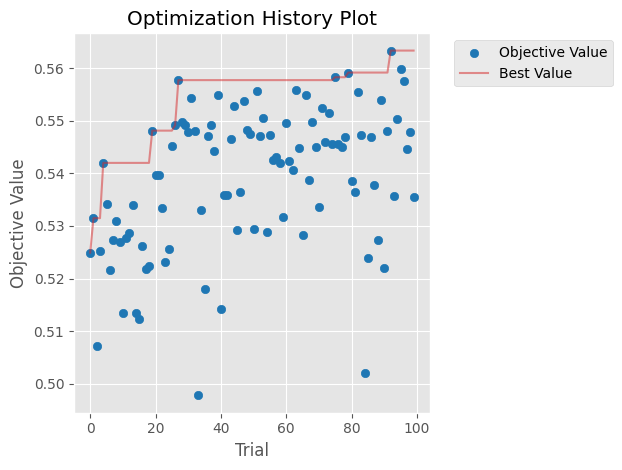

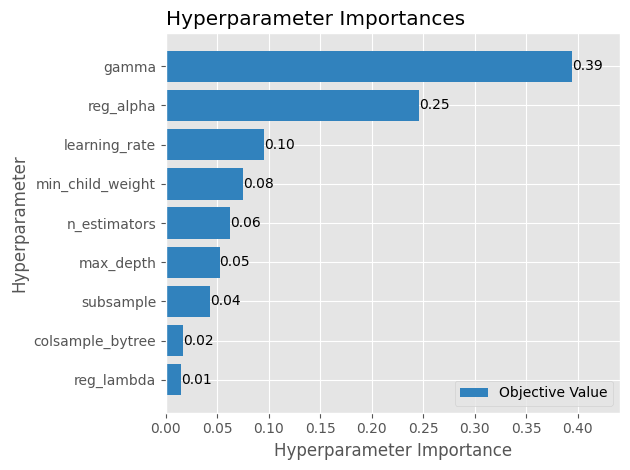

In [96]:
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.visualization.matplotlib import plot_param_importances

plot_optimization_history(study)
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.show()

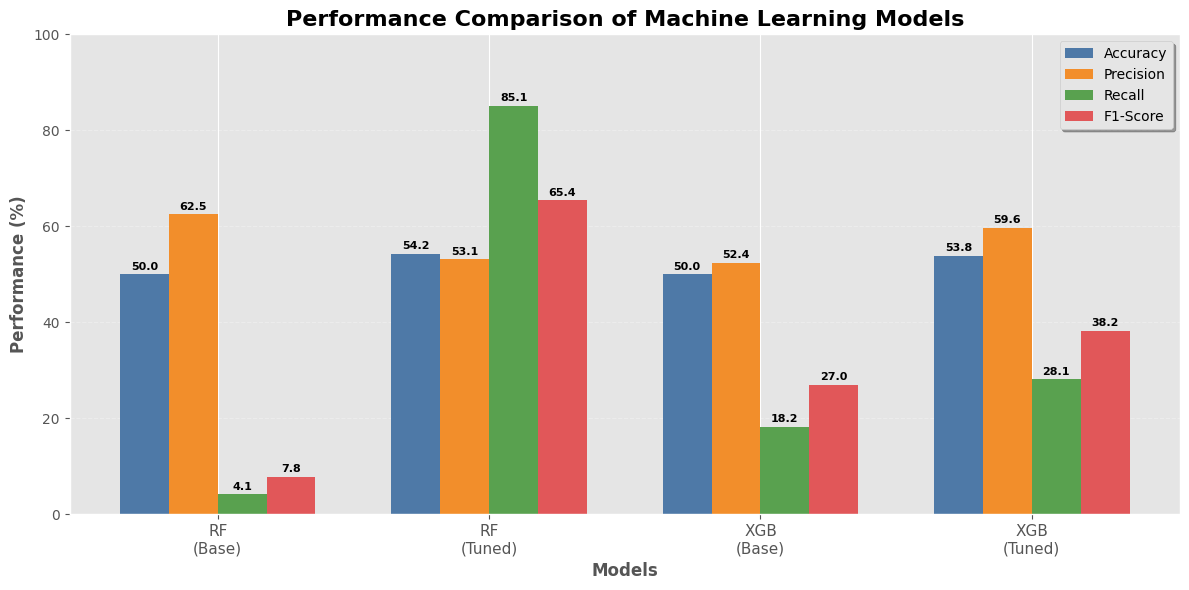

In [100]:
# ==========================================================
# PERFORMANCE COMPARISON OF MACHINE LEARNING MODELS
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# Models
models = [
    "RF\n(Base)",
    "RF\n(Tuned)",
    "XGB\n(Base)",
    "XGB\n(Tuned)"
]

# Metrics (%)
accuracy = [50.00, 54.20, 50.00, 53.78]
precision = [62.50, 53.09, 52.38, 59.65]
recall = [4.13, 85.12, 18.18, 28.10]
f1 = [7.75, 65.40, 26.99, 38.20]

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(12,6))

# Beautiful Colors
colors = {
    "Accuracy": "#4E79A7",     # Blue
    "Precision": "#F28E2B",    # Orange
    "Recall": "#59A14F",       # Green
    "F1": "#E15759"            # Red
}

bars1 = plt.bar(x-1.5*width, accuracy, width,
                label="Accuracy",
                color=colors["Accuracy"])

bars2 = plt.bar(x-0.5*width, precision, width,
                label="Precision",
                color=colors["Precision"])

bars3 = plt.bar(x+0.5*width, recall, width,
                label="Recall",
                color=colors["Recall"])

bars4 = plt.bar(x+1.5*width, f1, width,
                label="F1-Score",
                color=colors["F1"])


# Value Labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        plt.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+1,
            f"{bar.get_height():.1f}",
            ha='center',
            fontsize=8,
            fontweight='bold'
        )

plt.title(
    "Performance Comparison of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Performance (%)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(x, models, fontsize=11)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()

plt.show()